# Theta scaling analysis for MGD on LAGRANGIAN TURBULENCE data
Load data from an ensemble of experiments 

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
import math
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import * 
from utils_entropy import *
from filters_bank import * 
from check_moments import *
from potentials import *
from filters import *
from ortho_wavelet import *
from check_potentials import *  # theta_column_map, find_matching_reference_potentials, etc. -- this module used to be named theta_analysis_v2.py, see cell below



sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cpu
/home/chiaraz/phd/MGD-for-Maximum-Entropy-Generation/turbulence


In [ ]:
import os

# LOCAL vs JEAN ZAY: everything else in this notebook is agnostic to which
# side it's running on EXCEPT the two spots that hardcode/expect a Jean-Zay-
# only path -- load_turbulence_1d()'s default in data_loader.py, and
# selected_samples.pt below (item 7's rare/typical section). Flip this to
# "jean_zay" there instead of editing those cells.
RUN_LOCATION = "local"   # "local" or "jean_zay"

if RUN_LOCATION == "local":
    local_turbulence_path = (root / "../data/data_files/turbulence_1d_period.pt").resolve()
    if local_turbulence_path.exists():
        os.environ["TURBULENCE_1D_DATA_PATH"] = str(local_turbulence_path)
    else:
        print(f"WARNING: {local_turbulence_path} not found -- load_turbulence_1d() "
              f"will fall back to its Jean Zay default path and fail locally.")
# Evaluating a potential on the full n1=5000-sample batch at once can blow up
# memory: Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1.forward() materializes a
# ~5.9GB (5000, 24, 24, 512) intermediate BEFORE any reduction (measured
# directly -- DefaultCPUAllocator error asking for exactly 5898240000 bytes),
# regardless of how many seeds are loaded -- this is why the crash didn't move
# when seed count was cut. Chunking the batch through compute_phi_X below fixes
# it (verified: identical (5000, 84) output, ~1.5GB peak RSS with chunk_size=500)
# with no change to the result -- Jean Zay has enough RAM/GPU memory to skip this.
PHI_CHUNK_SIZE = 500 if RUN_LOCATION == "local" else None
print(f"RUN_LOCATION = {RUN_LOCATION!r}, PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE!r}")

In [2]:
# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials

def compute_phi_X(potentials, x1, chunk_size=PHI_CHUNK_SIZE):
    # chunk_size batches the sample dim through each potential's forward() --
    # see PHI_CHUNK_SIZE's comment above for why this matters locally.
    if chunk_size is None or x1.shape[0] <= chunk_size:
        starts = [0]
    else:
        starts = range(0, x1.shape[0], chunk_size)
    chunks = []
    for start in starts:
        x_chunk = x1 if chunk_size is None else x1[start:start + chunk_size]
        evaluated_features = []
        for p in potentials.values():
            feat = p(x_chunk)
            if feat.ndim == 1:
                feat = feat.unsqueeze(1)
            evaluated_features.append(feat)
        chunks.append(torch.cat(evaluated_features, dim=-1))
    return chunks[0] if len(chunks) == 1 else torch.cat(chunks, dim=0)

In [3]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [4]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [5]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [6]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(300, 313),   # 0 to 12
    range(313, 325),  # 13 to 24
    range(325, 338),  # 25 to 37
    range(338, 350)   # 38 to 49
]

for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")

    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder

    KEYS_TO_KEEP = {'theta_t', 'Theta_reg', 't'}
    potentials_by_seed = {} 
    for key, resolved_config in sorted(current_chunk_runs.items(),
                                        key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if loaded_data and loaded_data.get('loaded', False):
            # Some seeds' regularised fit was never computed/saved on the cluster --
            # load_results() then returns Theta_reg=None (verified locally: seed316,
            # seed327, seed332, seed343 have real theta_t but no
            # lagrange_multipliers_regularised file). Catch it HERE, once, instead of
            # every downstream cell needing its own "if Theta_reg is not None" check --
            # a seed missing Theta_reg is exactly as unusable as one that failed to load.
            if loaded_data.get('Theta_reg') is None:
                print(f"    -> Warning: {key} has no Theta_reg (regularised fit never "
                      f"saved), skipping.")
                del loaded_data
                continue
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
    
            # load_potentials_for_config/compute_phi_X raise (not caught inside
            # try_load_experiment) if a seed's on-disk artifacts are incomplete --
            # seen locally for real (seed331: empty fitted_potentials/ dir, likely
            # a partial sync from Jean Zay). Skip-with-warning here, same as the
            # try_load_experiment failure branch below, instead of crashing the
            # whole loop over one bad seed.
            try:
                potentials_k = load_potentials_for_config(
                    resolved_config, M, J=base_args.J, Q=base_args.Q,
                    terms=base_args.terms, root=root, device=device
                )
                phi_X_k = compute_phi_X(potentials_k, x1)
            except FileNotFoundError as e:
                print(f"    -> Warning: incomplete fitted_potentials for {key}, skipping: {e}")
                del loaded_data
                continue
            filtered_data['phi_X'] = phi_X_k
            filtered_data['num_potentials'] = phi_X_k.shape[-1]
    
            expected = filtered_data['theta_t'].shape[-1]
            if phi_X_k.shape[-1] != expected:
                print(f"    -> MISMATCH for {key}: skipping.")
                del loaded_data, potentials_k, phi_X_k
                continue
    
            results[key] = filtered_data
            config_by_seed[key] = resolved_config   # NEW — needed for lazy reload later
            potentials_by_seed[key] = potentials_k   # keep it — needed for compute_m1 later
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")
    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 300 to 312) ===
  [seed300] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  [seed301] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_301_terms2f1130a8_20260728_1232
  [seed302] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_302_terms2f1130a8_20260728_1232
  [seed303] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_303_terms2f1130a8_20260728_1232
  [seed304] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_304_terms2f1130a8_20260728_1232
  [seed305] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_305_terms2f1130a8_20260728_1232
  [seed306] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_306_terms2f1130a8_20260728_1232
  [seed307] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_307_t

In [7]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")

final_theta_MGD[seed_val].shape

# Convert dictionaries of 1D vectors into 2D tensors of shape (n_seeds, n_features)
reg_all = torch.stack([final_theta_reg[s] for s in seeds_sorted])
mgd_all = torch.stack([final_theta_MGD[s] for s in seeds_sorted])

print(f"Aggregated {len(seeds_sorted)} seeds into matrices of shape {reg_all.shape}.")


Collected final-time feature vectors for 50 seeds: Theta_reg has 272 features, theta_MGD has 272 features.
Aggregated 50 seeds into matrices of shape torch.Size([50, 272]).


In [8]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

## Histograms of the per-family energy components

Turbulence analogue of `theta_interpretation/theta_interpretation_analysis.ipynb`
section 5 (per-component energy histograms + total log p_theta(x)).

In the 1D toy Gaussian notebook, every term is scalar (`x2`, `x4`, ...), so
the "energy component" `theta_k * phi_k(x)` -- one summand of
`theta^T phi(x)`, the quantity that actually enters the fitted
log-density -- is already a single number per sample. Here each potential
*family* (`L_6`, `L_6_psi`, `Scattering_Fourth_Order_Mod2_Real_Q1`, ...) is
itself a whole block of coefficients, not one number, so the direct analogue
is the family's own dot product with its theta block:

`energy_family(x) = theta_family . phi_family(x) = sum_{k in family} theta_k * phi_k(x)`

This collapses each family -- regardless of how many coefficients it has --
down to one scalar per sample, so families of very different dimensionality
become directly comparable, and the family energies sum exactly to the
(unnormalized) total log-density `theta^T phi(x)`.

Evaluated on the real turbulence data `x1` (not samples drawn from the
fitted density, unlike the 1D notebook): sampling from a fitted
high-dimensional MGD needs a full SDE integration, which is a cluster job
here, not a notebook cell (see `CLAUDE.md`). Uses `Theta_reg[-1]` (the
regularized final theta) for one representative seed, matching the 1D
notebook's choice of `Theta_reg[-1]` throughout its section 5.

In [9]:
# ------------------------------------------------------------
# Per-family energy components theta_family . phi_family(x1), one scalar
# per real-data sample per family. Uses a single representative seed's
# fitted potentials + Theta_reg[-1] (own column layout, so no dependence
# on potential_ranges/potential_colors built later in the notebook from a
# pooled reference potential).
#
# Family column ranges come from theta_column_map() (codes/check_potentials.py),
# the same shared helper reused later in the notebook (cells 25/28/32/39) via
# find_matching_reference_potentials/build_all_averaged_vectors, instead of a
# second hand-rolled cumulative-sum loop -- it also validates
# sum(dims) == n_theta and raises a detailed per-potential diagnostic if a
# fitted potential was pruned to an unexpected width.
# ------------------------------------------------------------

ENERGY_SEED = seed_keys[0]
print(f"Using {ENERGY_SEED} ({config_by_seed[ENERGY_SEED]}) as the representative fit.")

potentials_energy = get_potentials_for_seed(ENERGY_SEED, M, base_args, root, device)
phi_X_energy = results[ENERGY_SEED]['phi_X'].detach().cpu()          # (n1, n_features), real data
theta_energy = results[ENERGY_SEED]['Theta_reg'][-1].detach().cpu()  # regularized final theta

col_map_energy = theta_column_map(potentials_energy, theta_energy.shape[-1])
family_ranges = {name: (start, start + dim) for name, (start, dim) in col_map_energy.items()}

# Double-check against the naive cumulative-sum-of-num_coefficients construction
# (same potentials.items() order) -- should agree exactly whenever no per-seed
# pruning has happened. theta_column_map is kept as the source of truth going
# forward since it also validates the total against n_theta.
_naive_ranges, _start = {}, 0
for name, p in potentials_energy.items():
    _dim = p.num_coefficients
    _naive_ranges[name] = (_start, _start + _dim)
    _start += _dim
assert family_ranges == _naive_ranges, (
    f"theta_column_map disagrees with the naive num_coefficients loop:\n"
    f"  theta_column_map: {family_ranges}\n  naive loop:       {_naive_ranges}"
)

assert phi_X_energy.shape[-1] == theta_energy.shape[-1], (
    f"phi_X feature dim ({phi_X_energy.shape[-1]}) doesn't match theta feature dim "
    f"({theta_energy.shape[-1]}) -- {ENERGY_SEED}'s fitted potentials don't match "
    f"its own saved theta/phi_X."
)

family_energy = {}   # name -> (n1,) array, theta_family . phi_family(x) per sample
for name, (a, b) in family_ranges.items():
    family_energy[name] = (theta_energy[a:b] * phi_X_energy[:, a:b]).sum(dim=-1).numpy()

total_log_p_unnorm = np.sum(np.stack(list(family_energy.values())), axis=0)  # theta^T phi(x), no log Z

print(f"\n{'family':45s} {'dim':>5s} {'mean':>12s} {'std':>12s}")
for name, (a, b) in family_ranges.items():
    comp = family_energy[name]
    print(f"{name:45s} {b-a:5d} {comp.mean():12.4g} {comp.std(ddof=1):12.4g}")


Using seed300 (turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232) as the representative fit.

family                                          dim         mean          std
L_6                                               9       -1.974        19.65
L_6_psi                                          25        3.646        16.74
L_2_lowpass                                       1        13.34        18.92
Scalar_psi_gaussianK                             70         1324        514.5
Scalar_morlet_gaussianK                          27       -457.6        194.2
Scattering_Fourth_Order_Mod2_Real_Q1             84        -11.3        52.75
Scattering_Fourth_Order_Mod2_Imag_Q1             56       0.1447        7.849


In [10]:
%matplotlib inline 

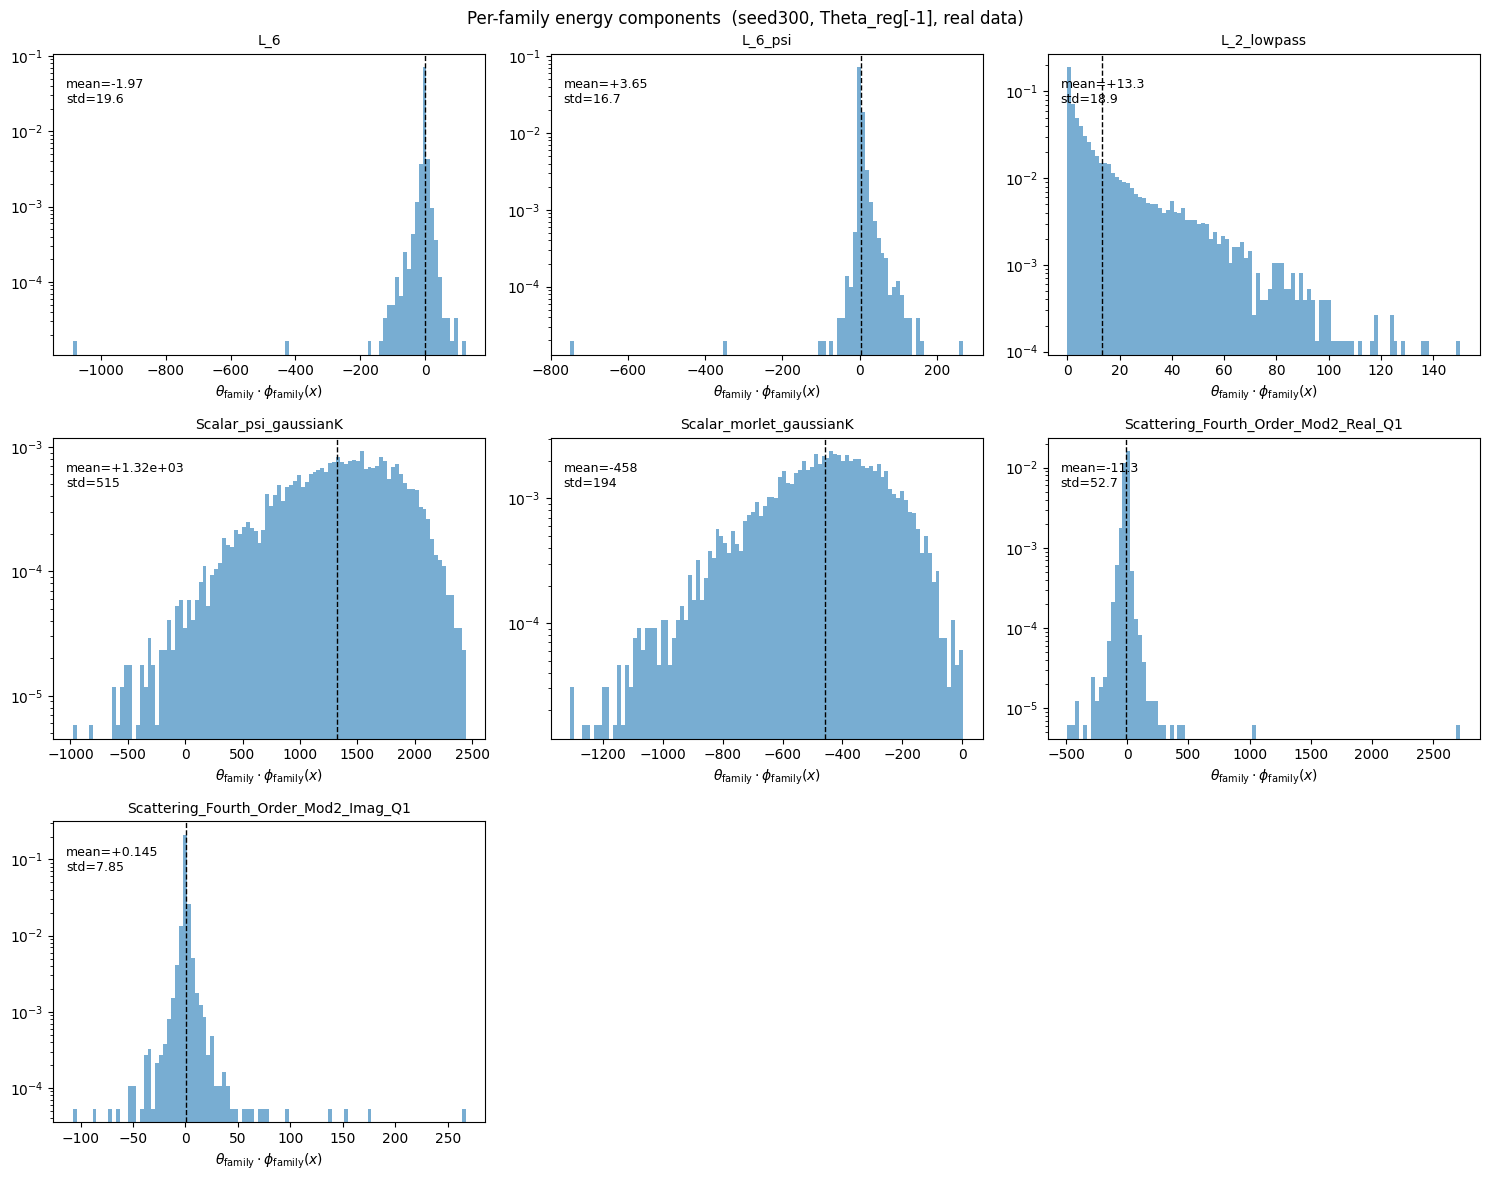

In [ ]:
# ------------------------------------------------------------
# One histogram per family: theta_family . phi_family(x), across the n1
# real-data samples. Log y-scale, same convention as the 1D notebook's
# energy-component histograms, since the tails are the informative part.
# ------------------------------------------------------------

n_families = len(family_energy)
n_cols = 3
n_rows = math.ceil(n_families / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, (name, comp) in enumerate(family_energy.items()):
    ax = axes[i // n_cols][i % n_cols]
    mean, std = comp.mean(), comp.std(ddof=1)
    ax.hist(comp, bins=100, density=True, alpha=0.6)
    ax.axvline(mean, color='k', ls='--', lw=1)
    ax.text(0.03, 0.92, f"mean={mean:+.3g}\nstd={std:.3g}",
            transform=ax.transAxes, fontsize=9, va='top')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(r'$\theta_{\mathrm{family}} \cdot \phi_{\mathrm{family}}(x)$')
    ax.set_yscale('log')

for j in range(n_families, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')

fig.suptitle(f"Per-family energy components  ({ENERGY_SEED}, Theta_reg[-1], real data)")
fig.tight_layout()
plt.show(); plt.close('all') 

,family,dim,mean,std,var
0,Scalar_psi_gaussianK,70,1324.068848,514.533875,264745.093750
1,Scalar_morlet_gaussianK,27,-457.556702,194.151871,37694.949219
2,Scattering_Fourth_Order_Mod2_Real_Q1,84,-11.303513,52.749096,2782.467285
3,L_6,9,-1.974127,19.649544,386.104553
4,L_2_lowpass,1,13.335847,18.921013,358.004761
5,L_6_psi,25,3.646330,16.738760,280.186096
6,Scattering_Fourth_Order_Mod2_Imag_Q1,56,0.144672,7.848684,61.601845


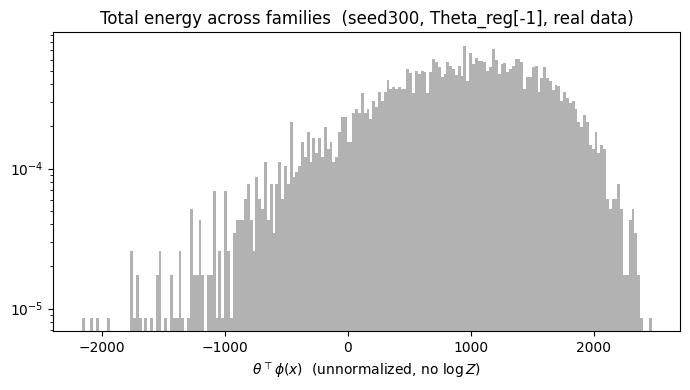

theta^T phi(x): mean=+870.4  std=708.9


In [ ]:
# ------------------------------------------------------------
# Summary table, sorted by variance -- which families' energy
# fluctuations dominate the total, i.e. which terms actually move
# theta^T phi(x) from sample to sample. Plus the total unnormalized
# log-density histogram (sum of all family energies), the turbulence
# analogue of the 1D notebook's log p_theta(x) histogram (section 5.2) --
# no log Z term since there's no cheap quadrature/bound normalizer wired
# up for this multi-family, high-dimensional case yet.
# ------------------------------------------------------------

energy_summary = pd.DataFrame([
    {
        'family': name,
        'dim': b - a,
        'mean': family_energy[name].mean(),
        'std': family_energy[name].std(ddof=1),
        'var': family_energy[name].var(ddof=1),
    }
    for name, (a, b) in family_ranges.items()
]).sort_values('var', ascending=False).reset_index(drop=True)
display(energy_summary)

plt.figure(figsize=(7, 4))
plt.hist(total_log_p_unnorm, bins=200, density=True, alpha=0.6, color='tab:gray')
plt.yscale('log')
plt.xlabel(r'$\theta^\top \phi(x)$  (unnormalized, no $\log Z$)')
plt.title(f'Total energy across families  ({ENERGY_SEED}, Theta_reg[-1], real data)')
plt.tight_layout()
plt.show()
plt.close('all') 

print(f"theta^T phi(x): mean={total_log_p_unnorm.mean():+.4g}  "
      f"std={total_log_p_unnorm.std(ddof=1):.4g}")

## Per-coefficient energy components (not summed within family)

Same `theta_energy` / `phi_X_energy` as the per-family energies above, but without the within-family `.sum(dim=-1)` -- one energy value `theta_k * phi_k(x)` per individual coefficient `k`, plotted across the full feature index with the family boundaries shaded in the background (same convention as `potential_colors` in the theta-scaling section below).

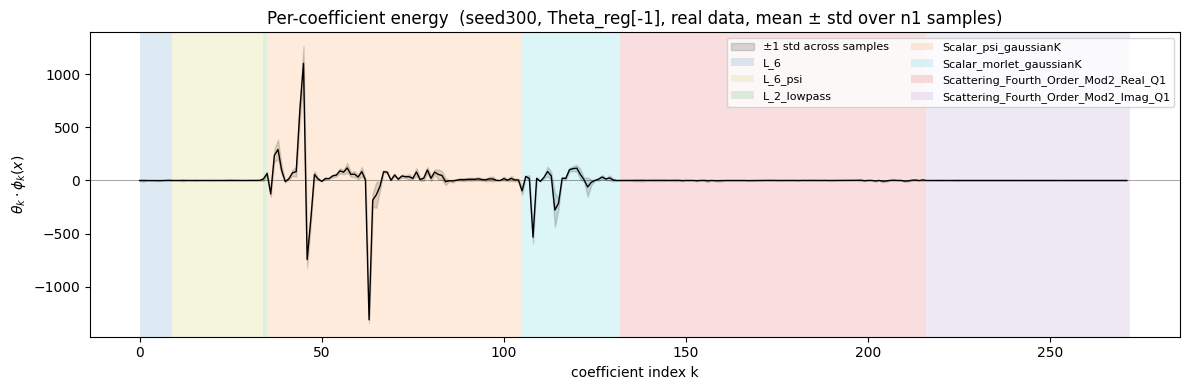

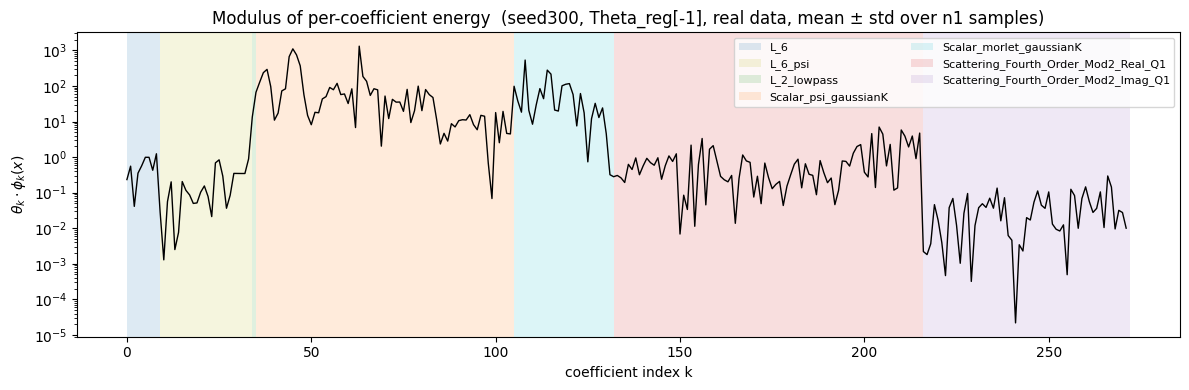

In [ ]:
# ------------------------------------------------------------
# Per-single-theta_k energy: theta_k * phi_k(x), NOT summed within family --
# same theta_energy / phi_X_energy as the per-family plot above, just without
# the family_energy[...] = (...).sum(dim=-1) reduction. Shaded with the same
# family-boundary color convention used later in the notebook (potential_colors,
# cell 38), duplicated here so this cell doesn't depend on a cell defined
# further down the notebook.
# ------------------------------------------------------------

energy_percoef = (theta_energy[None, :] * phi_X_energy).numpy()  # (n1, n_features)
percoef_mean = energy_percoef.mean(axis=0)
percoef_std = energy_percoef.std(axis=0, ddof=1)

_base_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive",
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan",
}
_fallback_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
family_colors = {
    name: _base_colors.get(name, _fallback_cycle[i % len(_fallback_cycle)])
    for i, name in enumerate(family_ranges.keys())
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(len(percoef_mean))
ax.plot(k, percoef_mean, color='black', lw=1)
ax.fill_between(k, percoef_mean - percoef_std, percoef_mean + percoef_std,
                 color='black', alpha=0.15, label='±1 std across samples')

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy  ({ENERGY_SEED}, Theta_reg[-1], real data, mean ± std over n1 samples)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
plt.close('all') 

# modulus energy, log scale 
fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(len(percoef_mean))
ax.plot(k, np.abs(percoef_mean), color='black', lw=1)

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Modulus of per-coefficient energy  ({ENERGY_SEED}, Theta_reg[-1], real data, mean ± std over n1 samples)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_yscale("log") 
fig.tight_layout()
plt.show()
plt.close('all') 


## Rare vs typical events: per-coefficient energy from `selected_samples.pt`

Loads `turbulence/selected_samples.pt` (built by `extract_samples.ipynb`, pulled from Jean Zay -- it isn't produced by anything that runs locally) -- a hand-picked `{"typical": [...], "rare": [...]}` set of raw turbulence snippets. Evaluates the same `ENERGY_SEED` fitted potentials (`potentials_energy`, `theta_energy` from the per-family energy section above) on each sample via `compute_phi_X` (cell 5), giving `theta_k * phi_k(x)` per coefficient per sample -- same family-shaded x-axis as the per-coefficient plot above, but one curve per individual real sample instead of a mean over `x1`.

In [14]:
samples_path = root / "selected_samples.pt"
if not samples_path.exists():
    if RUN_LOCATION == "jean_zay":
        raise FileNotFoundError(
            f"{samples_path} not found -- pull it from Jean Zay first, e.g.:\n"
            f"  rsync -avP <jean_zay_host>:/lustre/fswork/projects/rech/wbg/ukv59en/"
            f"MGD-for-Maximum-Entropy-Generation/turbulence/selected_samples.pt {samples_path}"
        )
    # RUN_LOCATION == "local" and the file isn't there: skip gracefully instead of
    # crashing the whole notebook -- samples={} makes every downstream cell in this
    # section (loops over samples.items()/sample_energy.items()) a silent no-op.
    print(f"WARNING: {samples_path} not found locally -- skipping the typical/rare "
          f"'selected samples' sections below (samples = {{}}).")
    samples = {}
else:
    samples = torch.load(samples_path, map_location=device)
    print({cat: (len(v), v[0].shape, v[0].dtype) for cat, v in samples.items()})

{'typical': (350, torch.Size([1, 256]), torch.float32), 'rare': (350, torch.Size([1, 256]), torch.float32)}


In [15]:
# Stack each category into a batch and evaluate the SAME representative
# seed's fitted potentials used above (potentials_energy / theta_energy from
# the per-family energy section) -- so coefficient ordering/count matches
# theta_energy automatically, via the notebook's own compute_phi_X (cell 5).
sample_energy = {}   # category -> (n_samples_in_category, n_features)
for category, tensors in samples.items():
    x_cat = torch.stack([t.to(device) for t in tensors], dim=0)
    if x_cat.ndim == 2:            # (n, L) -> (n, 1, L) if the channel dim got squeezed out
        x_cat = x_cat.unsqueeze(1)
    phi_cat = compute_phi_X(potentials_energy, x_cat).detach().cpu()
    assert phi_cat.shape[-1] == theta_energy.shape[-1], (
        f"'{category}': phi_X has {phi_cat.shape[-1]} features, theta_energy has "
        f"{theta_energy.shape[-1]} -- selected_samples.pt's preprocessing doesn't "
        f"match {ENERGY_SEED}'s fitted potentials."
    )
    sample_energy[category] = (theta_energy[None, :] * phi_cat).numpy()
    print(f"{category}: {sample_energy[category].shape[0]} samples")

typical: 350 samples
rare: 350 samples


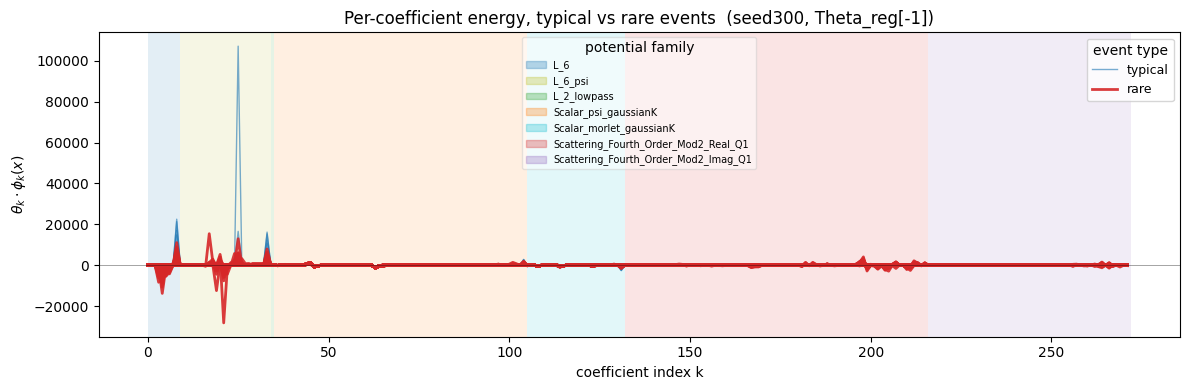

In [ ]:
category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.6),
    "rare":    dict(color="tab:red",  lw=2.0, alpha=0.9),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(theta_energy.shape[-1])

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.7))
    for i, curve in enumerate(energy):
        ax.plot(k, curve, label=category if i == 0 else None, **style)

# Two separate legends: one for typical/rare (line style), one for potential
# family (background color) -- built as proxy patches from family_colors
# rather than axvspan's own `label=`, so it doesn't get pulled into the
# typical/rare legend above.
category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in family_ranges]
ax.legend(family_handles, list(family_ranges.keys()), loc='upper center',
          fontsize=7, title='potential family', framealpha=0.5)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()
plt.close('all') 


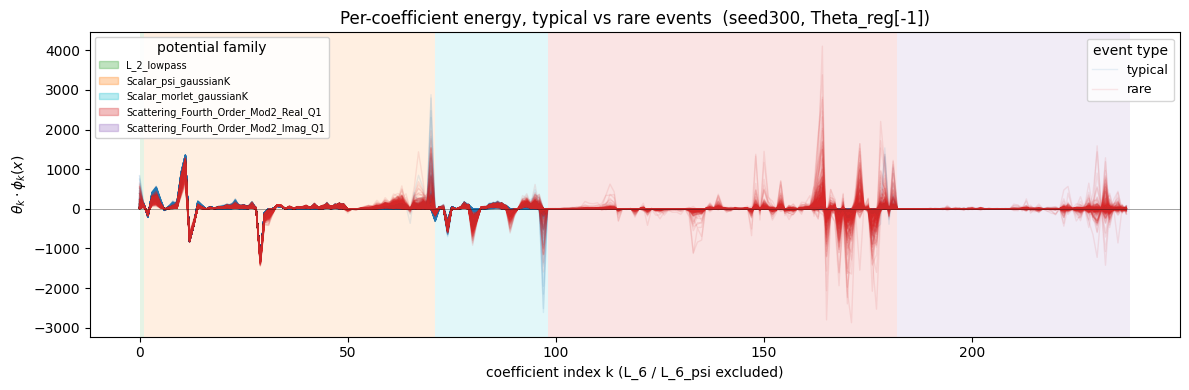

In [ ]:
EXCLUDED_FAMILIES = {"L_6", "L_6_psi"}

# Build a contiguous k-axis over the kept families only (not the full
# n_features range with holes for the excluded ones) -- same cumulative-
# offset idea as family_ranges itself, restricted to the families we keep.
kept_families = [name for name in family_ranges if name not in EXCLUDED_FAMILIES]
keep_mask = np.zeros(theta_energy.shape[-1], dtype=bool)
for name in kept_families:
    a, b = family_ranges[name]
    keep_mask[a:b] = True

family_ranges_plot = {}
start = 0
for name in kept_families:
    a, b = family_ranges[name]
    dim = b - a
    family_ranges_plot[name] = (start, start + dim)
    start += dim

category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.1),
    "rare":    dict(color="tab:red",  lw=1.0, alpha=0.1),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.2))
    for i, curve in enumerate(energy):
        ax.plot(k, curve[keep_mask], label=category if i == 0 else None, **style)

category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in kept_families]
ax.legend(family_handles, kept_families, loc='upper left',
          fontsize=7, title='potential family', framealpha=0.9)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k (L_6 / L_6_psi excluded)')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()
plt.close('all') 

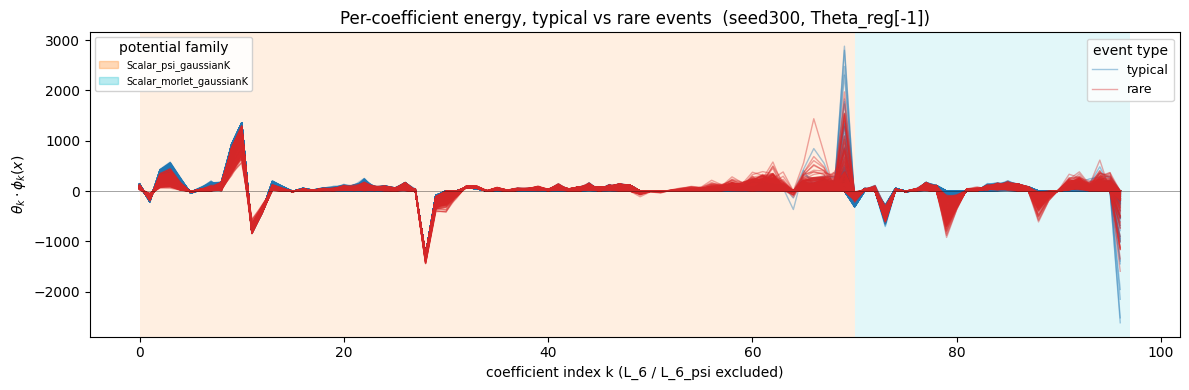

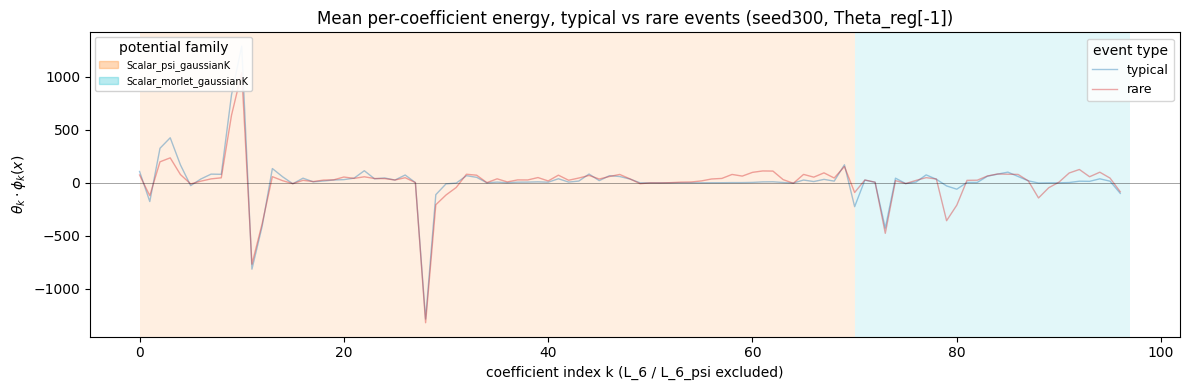

In [ ]:
EXCLUDED_FAMILIES = {"L_2_lowpass", "L_6", "L_6_psi", 
                     "Scattering_Fourth_Order_Mod2_Real_Q1", "Scattering_Fourth_Order_Mod2_Imag_Q1"}

# Build a contiguous k-axis over the kept families only (not the full
# n_features range with holes for the excluded ones) -- same cumulative-
# offset idea as family_ranges itself, restricted to the families we keep.
kept_families = [name for name in family_ranges if name not in EXCLUDED_FAMILIES]
keep_mask = np.zeros(theta_energy.shape[-1], dtype=bool)
for name in kept_families:
    a, b = family_ranges[name]
    keep_mask[a:b] = True

family_ranges_plot = {}
start = 0
for name in kept_families:
    a, b = family_ranges[name]
    dim = b - a
    family_ranges_plot[name] = (start, start + dim)
    start += dim

category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.4),
    "rare":    dict(color="tab:red",  lw=1.0, alpha=0.4),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.2))
    for i, curve in enumerate(energy):
        ax.plot(k, curve[keep_mask], label=category if i == 0 else None, **style)

category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in kept_families]
ax.legend(family_handles, kept_families, loc='upper left',
          fontsize=7, title='potential family', framealpha=0.9)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k (L_6 / L_6_psi excluded)')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()
plt.close('all') 



#### only the average 
fig, ax = plt.subplots(figsize=(12, 4))

k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():

    # Mean over samples in this category
    mean_curve = np.mean(
        np.stack([curve[keep_mask] for curve in energy]),
        axis=0
    )

    style = category_style.get(category, dict(lw=2.0))
    ax.plot(
        k,
        mean_curve,
        label=category,
        **style
    )

# Background shading for potential families
for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(
        a, b,
        color=family_colors[name],
        alpha=0.12,
        lw=0
    )

# Legend for event type
category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(
    category_handles,
    category_labels,
    loc="upper right",
    fontsize=9,
    title="event type"
)
ax.add_artist(category_legend)

# Legend for potential families
family_handles = [
    plt.Rectangle(
        (0, 0), 1, 1,
        color=family_colors[name],
        alpha=0.3
    )
    for name in kept_families
]

ax.legend(
    family_handles,
    kept_families,
    loc="upper left",
    fontsize=7,
    title="potential family",
    framealpha=0.9
)

ax.axhline(0, color="black", lw=0.5, alpha=0.5)

ax.set_xlabel("coefficient index k (L_6 / L_6_psi excluded)")
ax.set_ylabel(r"$\theta_k \cdot \phi_k(x)$")
ax.set_title(
    f"Mean per-coefficient energy, typical vs rare events "
    f"({ENERGY_SEED}, Theta_reg[-1])"
)

fig.tight_layout()
plt.show()
plt.close('all') 

## Only scattering order 4 (real and imag) 

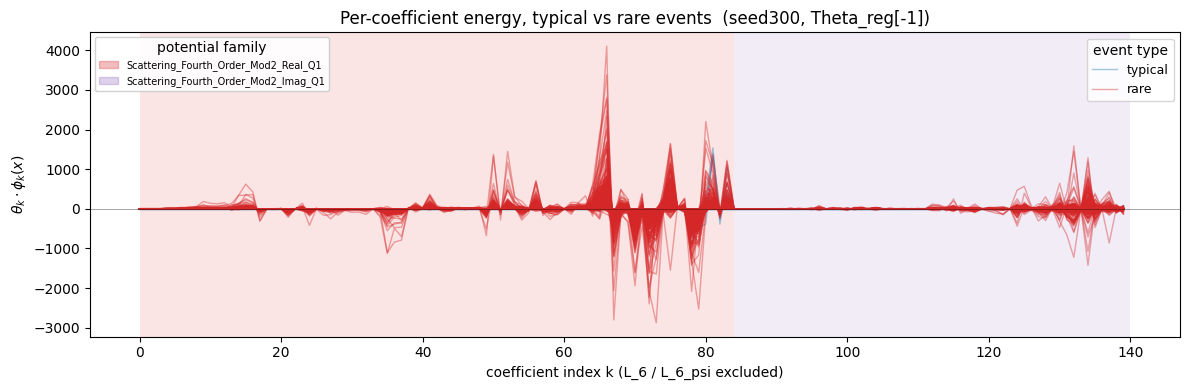

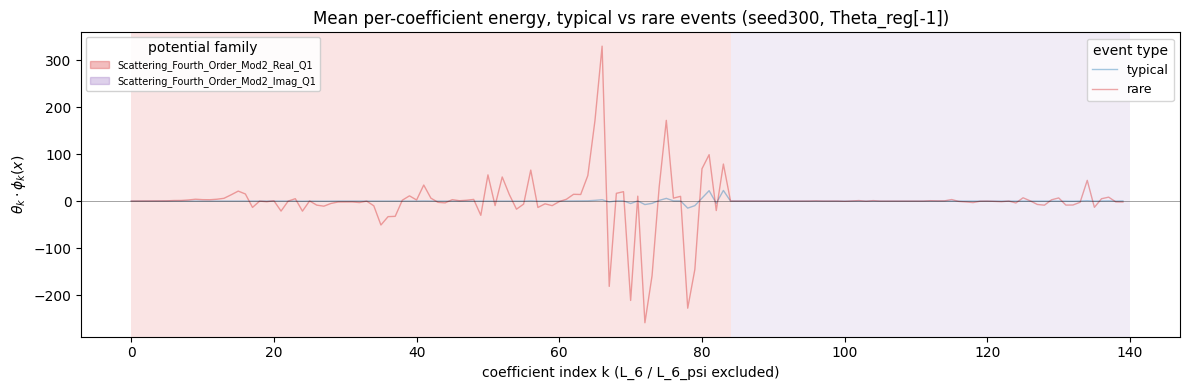

In [ ]:
EXCLUDED_FAMILIES = {"L_2_lowpass", "L_6", "L_6_psi", 
                     "Scalar_psi_gaussianK", "Scalar_morlet_gaussianK"}

# Build a contiguous k-axis over the kept families only (not the full
# n_features range with holes for the excluded ones) -- same cumulative-
# offset idea as family_ranges itself, restricted to the families we keep.
kept_families = [name for name in family_ranges if name not in EXCLUDED_FAMILIES]
keep_mask = np.zeros(theta_energy.shape[-1], dtype=bool)
for name in kept_families:
    a, b = family_ranges[name]
    keep_mask[a:b] = True

family_ranges_plot = {}
start = 0
for name in kept_families:
    a, b = family_ranges[name]
    dim = b - a
    family_ranges_plot[name] = (start, start + dim)
    start += dim

category_style = {
    "typical": dict(color="tab:blue", lw=1.0, alpha=0.4),
    "rare":    dict(color="tab:red",  lw=1.0, alpha=0.4),
}

fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():
    style = category_style.get(category, dict(lw=1.0, alpha=0.2))
    for i, curve in enumerate(energy):
        ax.plot(k, curve[keep_mask], label=category if i == 0 else None, **style)

category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(category_handles, category_labels, loc='upper right',
                             fontsize=9, title='event type')
ax.add_artist(category_legend)

for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(a, b, color=family_colors[name], alpha=0.12, lw=0)

family_handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[name], alpha=0.3)
                   for name in kept_families]
ax.legend(family_handles, kept_families, loc='upper left',
          fontsize=7, title='potential family', framealpha=0.9)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k (L_6 / L_6_psi excluded)')
ax.set_ylabel(r'$\theta_k \cdot \phi_k(x)$')
ax.set_title(f'Per-coefficient energy, typical vs rare events  ({ENERGY_SEED}, Theta_reg[-1])')
fig.tight_layout()
plt.show()
plt.close('all') 



#### only the average 
fig, ax = plt.subplots(figsize=(12, 4))

k = np.arange(keep_mask.sum())

for category, energy in sample_energy.items():

    # Mean over samples in this category
    mean_curve = np.mean(
        np.stack([curve[keep_mask] for curve in energy]),
        axis=0
    )

    style = category_style.get(category, dict(lw=2.0))
    ax.plot(
        k,
        mean_curve,
        label=category,
        **style
    )

# Background shading for potential families
for name, (a, b) in family_ranges_plot.items():
    ax.axvspan(
        a, b,
        color=family_colors[name],
        alpha=0.12,
        lw=0
    )

# Legend for event type
category_handles, category_labels = ax.get_legend_handles_labels()
category_legend = ax.legend(
    category_handles,
    category_labels,
    loc="upper right",
    fontsize=9,
    title="event type"
)
ax.add_artist(category_legend)

# Legend for potential families
family_handles = [
    plt.Rectangle(
        (0, 0), 1, 1,
        color=family_colors[name],
        alpha=0.3
    )
    for name in kept_families
]

ax.legend(
    family_handles,
    kept_families,
    loc="upper left",
    fontsize=7,
    title="potential family",
    framealpha=0.9
)

ax.axhline(0, color="black", lw=0.5, alpha=0.5)

ax.set_xlabel("coefficient index k (L_6 / L_6_psi excluded)")
ax.set_ylabel(r"$\theta_k \cdot \phi_k(x)$")
ax.set_title(
    f"Mean per-coefficient energy, typical vs rare events "
    f"({ENERGY_SEED}, Theta_reg[-1])"
)

fig.tight_layout()
plt.show()
plt.close('all') 

## Real vs. remapped-imaginary scattering energy, per trajectory

Compares `theta_k * phi_k(x)` for `Scattering_Fourth_Order_Mod2_Real_Q1` against
the same quantity for `Scattering_Fourth_Order_Mod2_Imag_Q1`, remapped onto the
real branch's coefficient layout via `expand_imag_to_real_indices` (same index
matching used elsewhere in this notebook for this potential pair, `index_convention='mod2'`).
One color per individual `selected_samples.pt` trajectory, shared with the raw
signal panel below it, so a given curve's source is identifiable.

In [20]:
REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"

pot_re = potentials_energy[REAL_KEY]
pot_im = potentials_energy[IMAG_KEY]
a_re, b_re = family_ranges[REAL_KEY]
a_im, b_im = family_ranges[IMAG_KEY]

scatter_energy = {}   # category -> {'real': (n, dim_re), 'imag_remapped': (n, dim_re)}
for category, energy in sample_energy.items():
    energy_real = energy[:, a_re:b_re]           # (n, dim_re), real branch's own layout
    energy_imag_own = energy[:, a_im:b_im]        # (n, dim_im), imaginary branch's own layout
    energy_imag_remapped = expand_imag_to_real_indices(
        pot_im, pot_re, energy_imag_own, index_convention='mod2',
    )                                              # (n, dim_re), zero-padded onto real's layout
    scatter_energy[category] = dict(real=energy_real, imag_remapped=energy_imag_remapped)
    print(f"{category}: real {energy_real.shape}, imag remapped {energy_imag_remapped.shape}")

typical: real (350, 84), imag remapped (350, 84)
rare: real (350, 84), imag remapped (350, 84)


In [ ]:
# Extracted from the "Theta scaling plots" cell below (heavy: loops compute_mk()/
# build_complex_theta_dataframe() over every seed, i.e. the same unchunked
# per-seed forward() cost as the phi_X blowup fixed earlier, but now x46 --
# safe to skip that whole cell (and the two after it that consume its output:
# mgd_vectors/reg_vectors/energy_mgd/energy_reg are never referenced past cell 39,
# and the one place downstream that COULD use energy_reg already guards with
# `if 'energy_reg' in globals()`). These 3 constants are the only things from
# that block anything later actually needs.
REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

## Theta scaling analysis 

### Theta scaling plots 

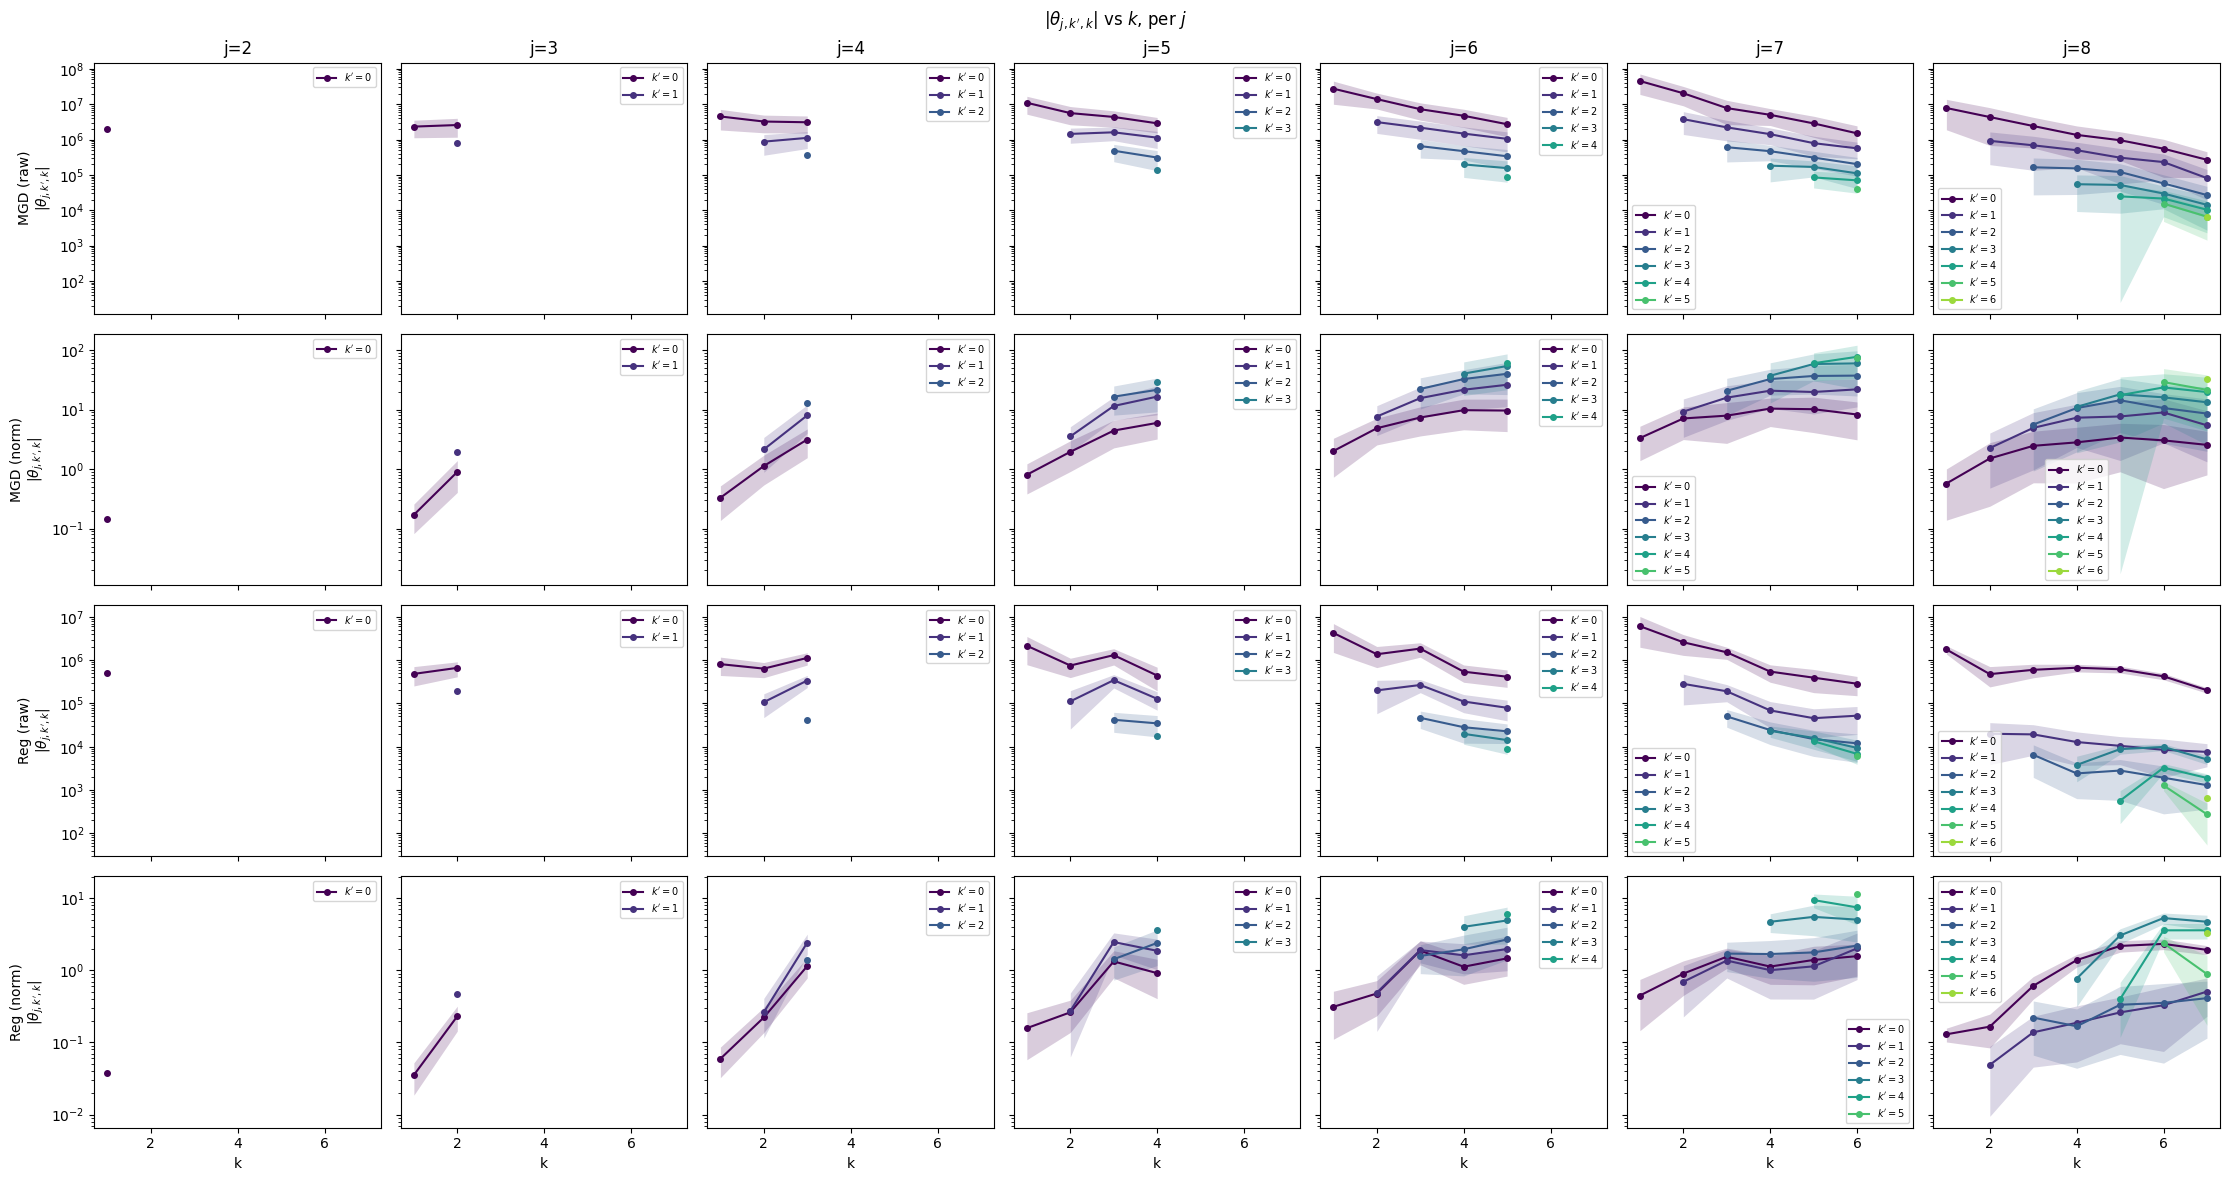

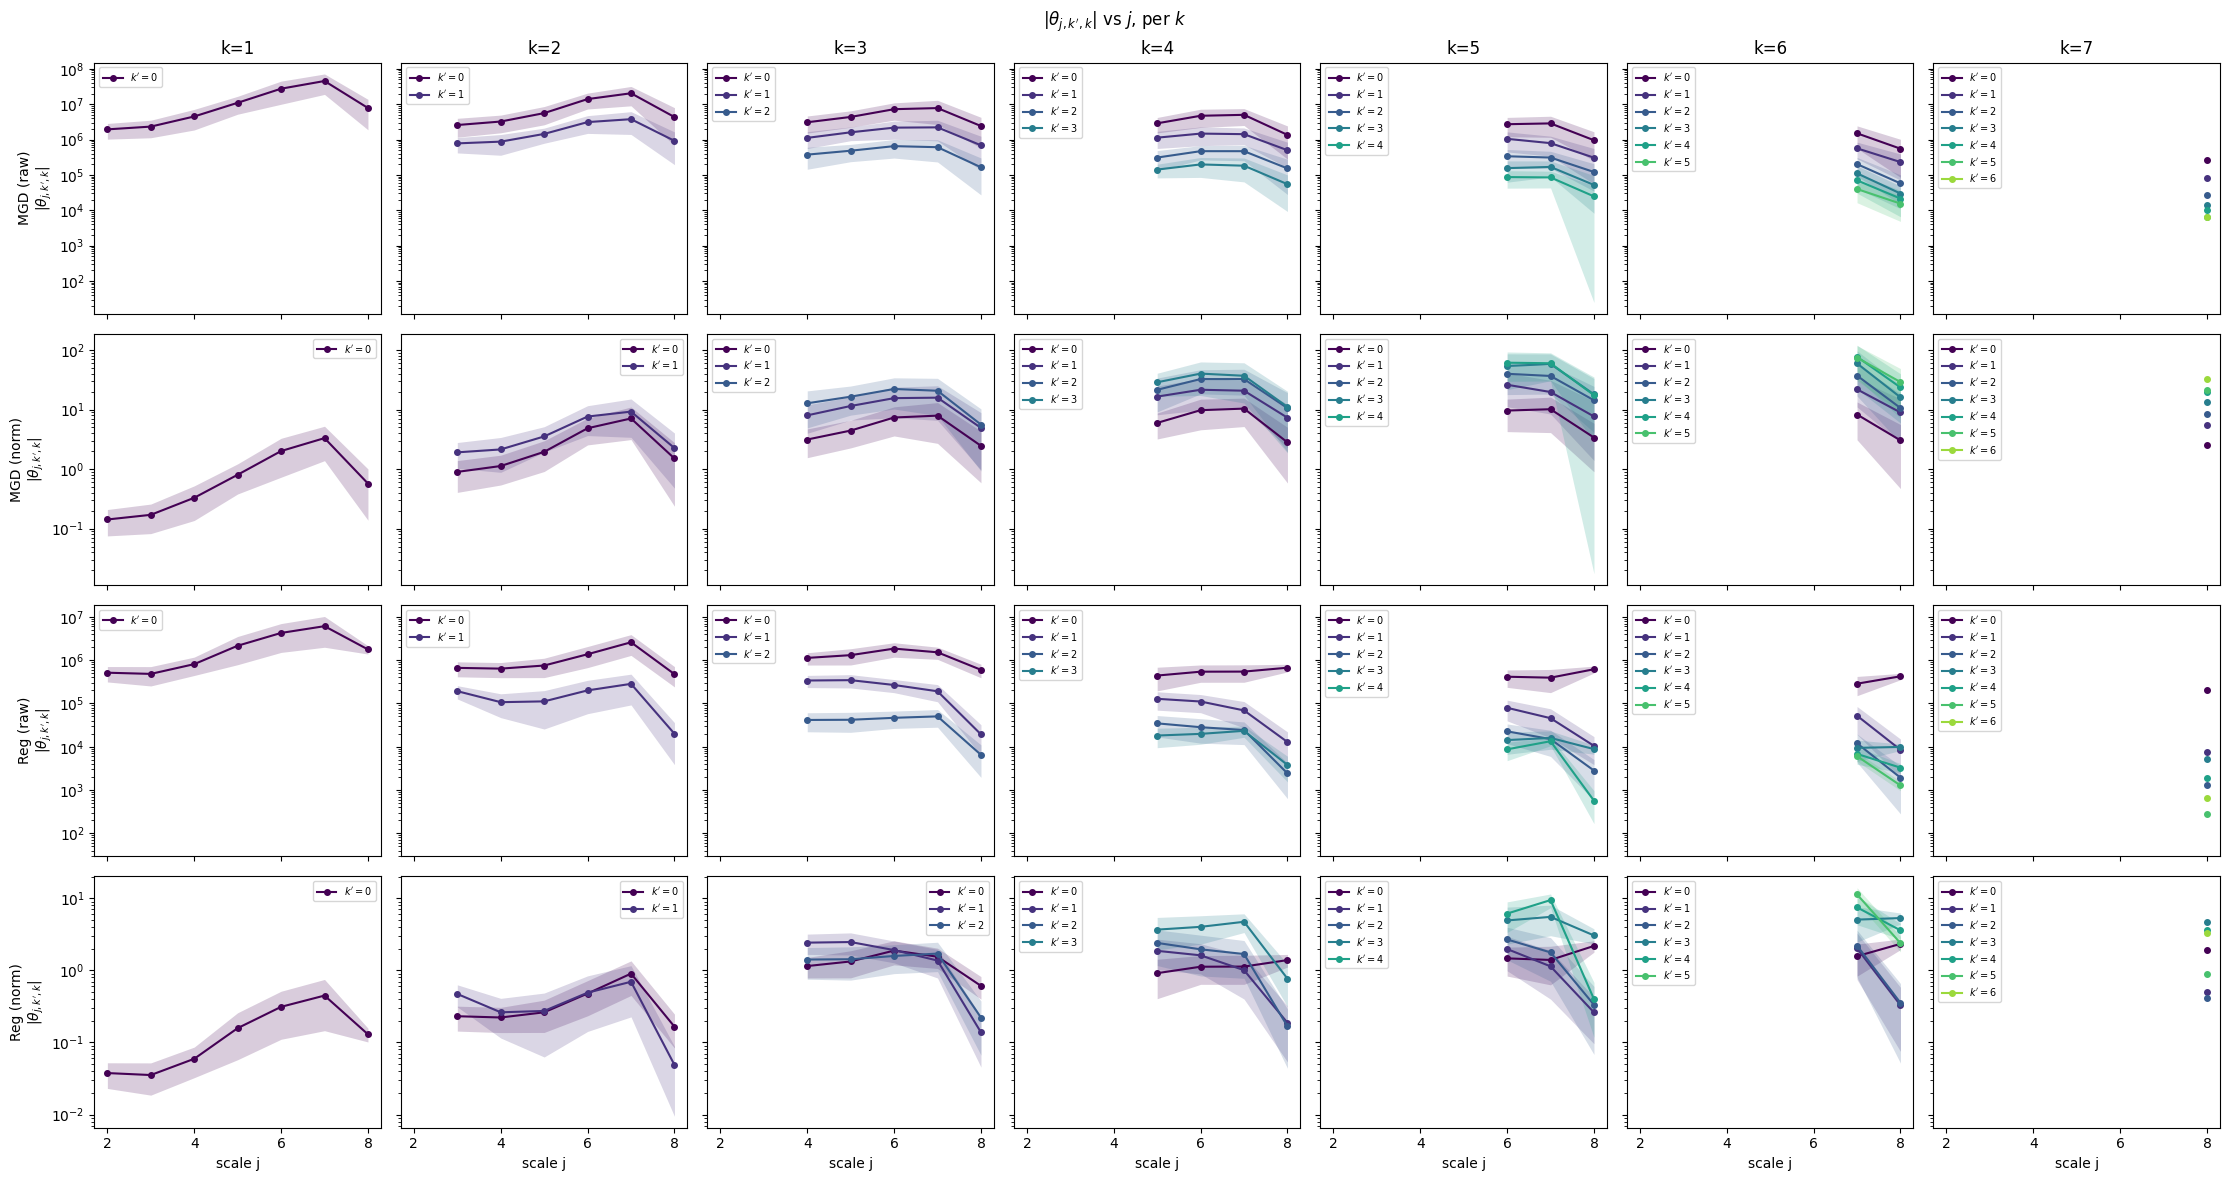

In [21]:
# Replaces the bottom section of the notebook (from
# "Build per-seed dataframes for theta_MGD and theta_reg..." onward).
# Everything above (results loading, reg_all/mgd_all, potential_ranges,
# terms, base_args, root, device, x1, filters) is unchanged. `filters` here
# is the notebook's J+1-channel single-layer filter bank
# (filters = return_Filters(M, J, 1, device=device)) -- it's only used as a
# fallback inside compute_norm_jab if a potential doesn't carry its own
# `.filters` attribute; in practice every potential you've fitted does, so
# pot_re.filters is what actually gets used.

# NOTE: compute_mk, build_theta_dataframe, build_complex_theta_dataframe,
# build_agg_cases, plot_modulus_vs_k_grid, plot_modulus_vs_j_grid,
# build_all_averaged_vectors, find_matching_reference_potentials etc. now come
# from `from check_potentials import *` in cell 1 -- this module used to be
# named theta_analysis_v2.py (see its docstring), which is why that import
# target no longer existed and this cell was left as a non-executed raw cell.

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

# ------------------------------------------------------------
# 1. Per-seed complex dataframes for the Real+i*Imag scattering coefficient
# ------------------------------------------------------------
dfs = {}              # MGD
dfs_reg = {}           # Reg
potentials_by_seed = {}  # keep each seed's FITTED potentials -- needed below,
                          # since their pruned layout is what actually matches
                          # theta_t on disk, not the nominal get_1d_potentials(...)
mk_by_seed = {}        # matching m_k vector for each seed's fitted potentials
                        # (kept as an optional fallback normalization for
                        # potentials without scattering .indices; the Mod2
                        # pair itself now normalizes via compute_norm_jab)

for key in sorted(results.keys(), key=lambda s: int(s.replace("seed", ""))):
    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)
    potentials_by_seed[key] = potentials_k
    m_k = compute_mk(potentials_k, x1)
    mk_by_seed[key] = m_k

    theta_final = results[key]["theta_t"][-1]
    dfs[key] = build_complex_theta_dataframe(
        theta_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
        # norm_order left as None -> auto-inferred to 4 since 'Mod2' is in REAL_KEY
    )

    theta_reg_final = results[key]["Theta_reg"][-1]
    dfs_reg[key] = build_complex_theta_dataframe(
        theta_reg_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
    )

# ------------------------------------------------------------
# 2. |theta_complex| vs k (per j) and vs j (per k), MGD vs Reg, raw + normalized
# ------------------------------------------------------------
cases = {
    'MGD (raw)':  {'dfs': dfs,     'value_col': 'theta_complex'},
    'MGD (norm)': {'dfs': dfs,     'value_col': 'theta_complex_normalized'},
    'Reg (raw)':  {'dfs': dfs_reg, 'value_col': 'theta_complex'},
    'Reg (norm)': {'dfs': dfs_reg, 'value_col': 'theta_complex_normalized'},
}
agg_cases = build_agg_cases(cases)

%matplotlib inline 
plot_modulus_vs_k_grid(agg_cases)   # |theta_complex| vs k, one panel per j
plot_modulus_vs_j_grid(agg_cases)   # |theta_complex| vs j, one panel per k

### Compare $\theta_k m_k$ interacting and not-interacting energy components 

Using seed300's fitted potentials for MGD vectors, seed300's for Reg vectors.
L_6                                      shape=(9,)  (real)
L_6_psi                                  shape=(25,)  (real)
L_2_lowpass                              shape=(1,)  (real)
Scalar_psi_gaussianK                     shape=(70,)  (real)
Scalar_morlet_gaussianK                  shape=(27,)  (real)
Scattering_Fourth_Order_Mod2_Q1          shape=(84,)  (complex)
K                4
J                25
num_coefficients 70
Keff             tensor shape=(25,) dtype=torch.int64
active           tensor shape=(25, 4) dtype=torch.bool
active_flat      tensor shape=(70,) dtype=torch.int64
scale            tensor shape=(25, 4) dtype=torch.float32
alpha            tensor shape=(25, 4) dtype=torch.float32
cuts             tensor shape=(25, 3) dtype=torch.float32
pi               tensor shape=(25, 4) dtype=torch.float32
sw               tensor shape=(25, 3) dtype=torch.float32
stat_scale       tensor shape=(70,) dtype=t

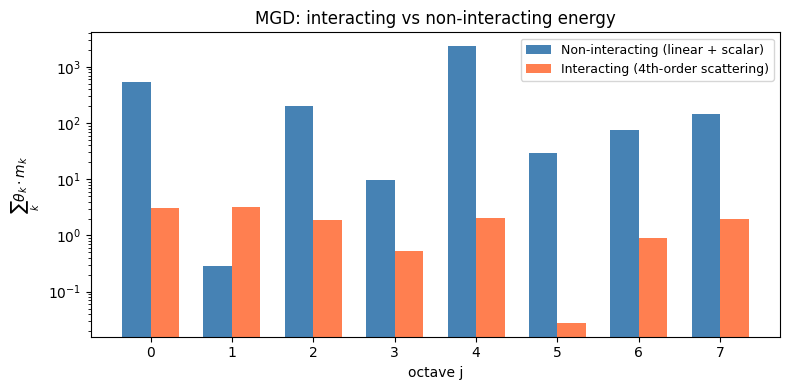

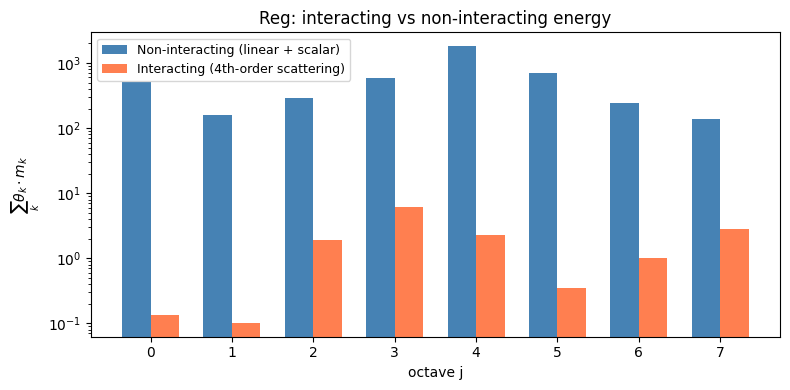

theta_k stdPhi_k, all positive


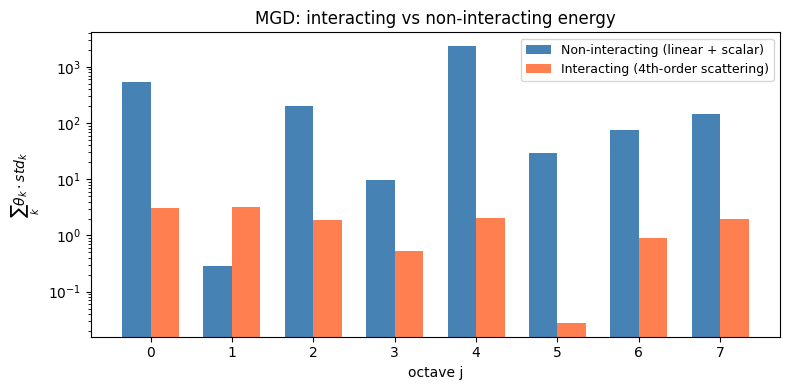

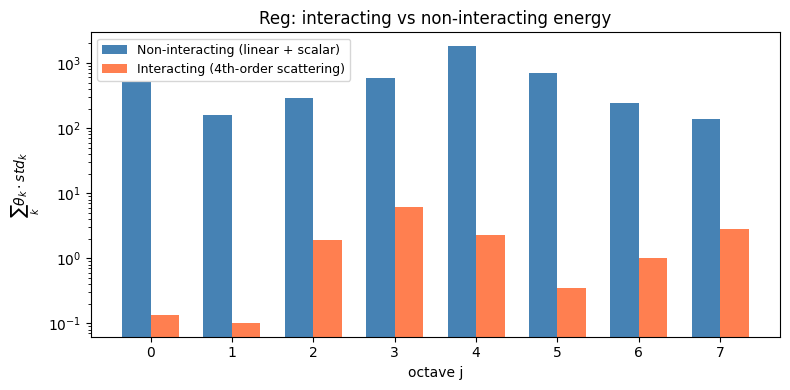

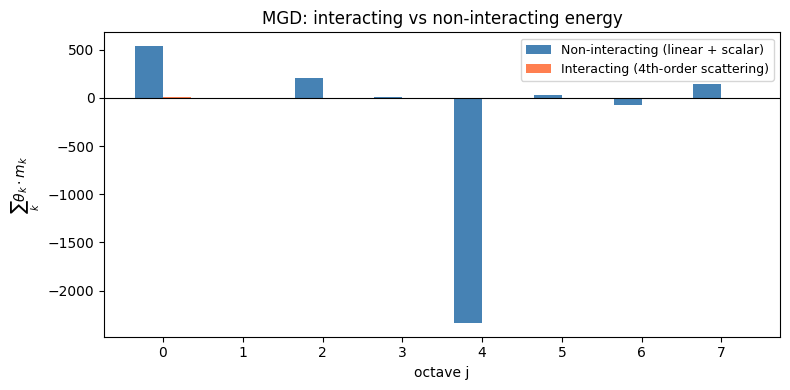

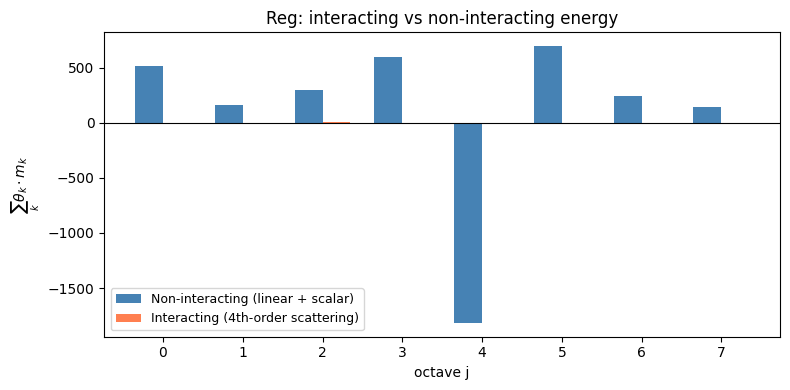

In [22]:

# ------------------------------------------------------------
# 3. Readable, seed-averaged theta vectors for every potential
#    (Real_Q1 + i*Imag_Q1 collapsed into one complex vector; everything
#    else -- L_6, L_6_psi, L_2_lowpass, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK -- stays real)
#
#    Use a reference seed's FITTED potentials (whichever one's pruned
#    layout actually sums to mgd_all's column count) instead of the
#    nominal `potentials` from get_1d_potentials(...) at the top of the
#    notebook -- that nominal one reflects theoretical, un-pruned sizes
#    and will trip the sum(dims) != n_theta assertion.
# ------------------------------------------------------------
real_imag_pairs = [(REAL_KEY, IMAG_KEY, COMPLEX_NAME)]

ref_seed_mgd, ref_potentials_mgd, _ = find_matching_reference_potentials(mgd_all, potentials_by_seed)
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
print(f"Using {ref_seed_mgd}'s fitted potentials for MGD vectors, {ref_seed_reg}'s for Reg vectors.")

mgd_vectors = build_all_averaged_vectors(mgd_all, ref_potentials_mgd, terms, real_imag_pairs=real_imag_pairs)
reg_vectors = build_all_averaged_vectors(reg_all, ref_potentials_reg, terms, real_imag_pairs=real_imag_pairs)

# e.g.:
#   mgd_vectors['L_6']                          -> real, shape (9,)
#   mgd_vectors['L_6_psi']                      -> real, shape (25,)
#   mgd_vectors['Scattering_Fourth_Order_Mod2_Q1']  -> complex
#   reg_vectors['Scalar_psi_gaussianK']         -> real

for name, vec in mgd_vectors.items():
    kind = 'complex' if np.iscomplexobj(vec) else 'real'
    print(f"{name:40s} shape={vec.shape}  ({kind})")

# ------------------------------------------------------------
# 4. Matching m_k vectors + octave-level "interacting vs non-interacting"
#    energy comparison: theta_k * m_k, summed within each octave j.
#
#    Non-interacting: L_6, L_6_psi, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK (octave-structured) + L_2_lowpass (pure scalar).
#    Interacting: the Real+i*Imag 4th-order scattering potential.
#
#    "psi"-family potentials use Q=3, "morlet"-family use Q=1 -- adjust
#    potential_QJ below if that naming-based guess is wrong for your setup.
# ------------------------------------------------------------

# mk_all must be stacked in the SAME seed order used for mgd_all/reg_all
# (seeds_sorted). If mk_by_seed's key format ("seedN") differs from
# seeds_sorted's (plain ints), adjust the lookup below to match.
mk_all = torch.stack([torch.as_tensor(mk_by_seed[f"seed{s}"]) for s in seeds_sorted])
assert mk_all.shape[0] == mgd_all.shape[0], (
    "mk_all and mgd_all have different seed counts -- their seed sets/order "
    "must match for the vectors below to line up."
)

ref_seed_mk, ref_potentials_mk, _ = find_matching_reference_potentials(mk_all, potentials_by_seed)
mk_vectors = build_all_averaged_vectors(mk_all, ref_potentials_mk, terms, real_imag_pairs=real_imag_pairs)

# --- FIRST: sanity-check the Scalar_* potentials' channel structure on a
# real, fitted object before trusting anything below. Run this once and
# read the output -- Keff/active_flat should be populated (unlike the
# unfitted `potentials` dict), and num_coefficients should equal
# active_flat.sum() / Keff.sum().
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_psi_gaussianK"])
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_morlet_gaussianK"])

J = base_args.J
potential_specs = {
    'L_6':     ('QJ', 1),
    'L_6_psi': ('QJ', 3),
    'Scalar_morlet_gaussianK': ('scalar', ref_potentials_mgd["Scalar_morlet_gaussianK"], 1),
    'Scalar_psi_gaussianK':    ('scalar', ref_potentials_mgd["Scalar_psi_gaussianK"], 3),
}
# j2 (coarse, second-layer) index for each scattering coefficient, decoded
# from a real potential whose layout matches theta_vectors[COMPLEX_NAME] --
# i.e. the reference potential used to build mgd_vectors/reg_vectors, not
# the nominal one. Uses decode_mod2_stq (NOT decode_jab): verified against
# Scattering_Fourth_Order_Mod2_Real_1d's actual forward()/fit_micro tensor
# shapes, j2 ranges over [0,J] (J+1 values incl. low-pass) -- decode_jab
# assumed a structurally different, incompatible axis layout for this
# potential family. Ranges over [0,J], so build_octave_energy_comparison
# groups it into J+1 bins internally and reports the low-pass one
# separately (energy_dict['interacting_lowpass']).
_, s1_indices_scatter, s2_indices_scatter = decode_mod2_stq(ref_potentials_mgd[REAL_KEY], verbose=False)
Q_scatter = ref_potentials_mgd[REAL_KEY].Q   # =1 for the _Q1 potentials used here

energy_mgd = build_octave_energy_comparison(
    mgd_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)
energy_reg = build_octave_energy_comparison(
    reg_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)

energy_mgd_std = build_octave_energy_comparison(
    mgd_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],  energy_kind='std', 
)
energy_reg_std = build_octave_energy_comparison(
    reg_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],  energy_kind='std', 
)

print("\nMGD -- non-interacting energy per octave:", energy_mgd['non_interacting_total'])
print("MGD -- interacting energy per octave:    ", energy_mgd['interacting'])
print("MGD -- non-interacting low-pass total:   ", energy_mgd['non_interacting_lowpass_total'])

%matplotlib inline 
print("theta_k m_k, all positive") 
plot_octave_energy_comparison(energy_mgd, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, all_positive = True, title='Reg: interacting vs non-interacting energy')

print("theta_k stdPhi_k, all positive") 
plot_octave_energy_comparison(energy_mgd_std, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg_std, all_positive = True, title='Reg: interacting vs non-interacting energy')

plot_octave_energy_comparison(energy_mgd, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, title='Reg: interacting vs non-interacting energy')

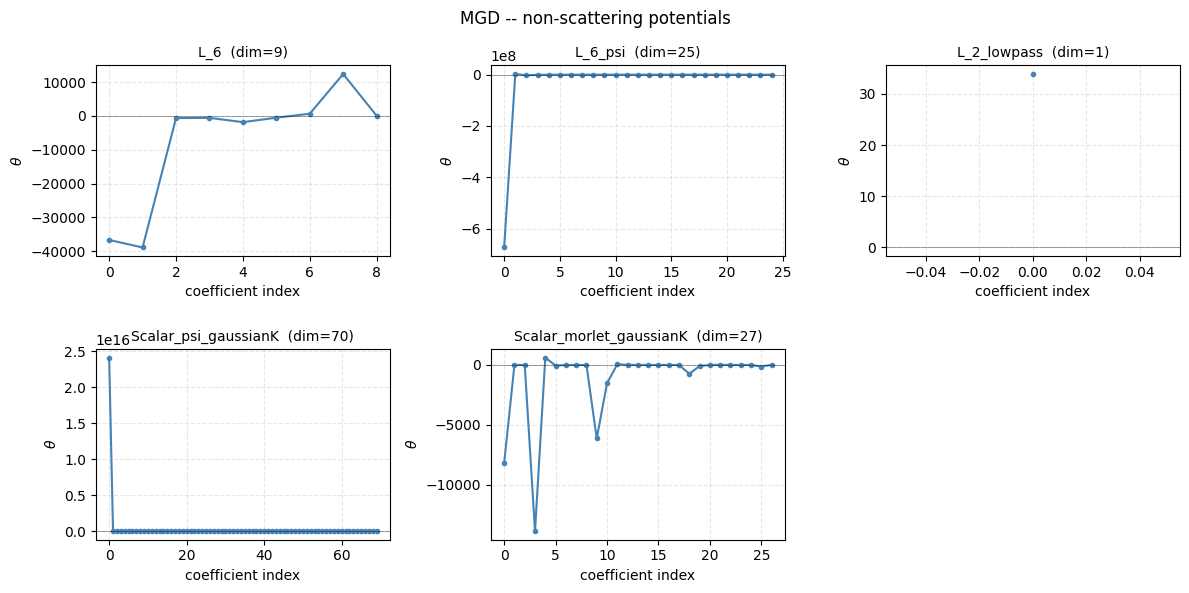

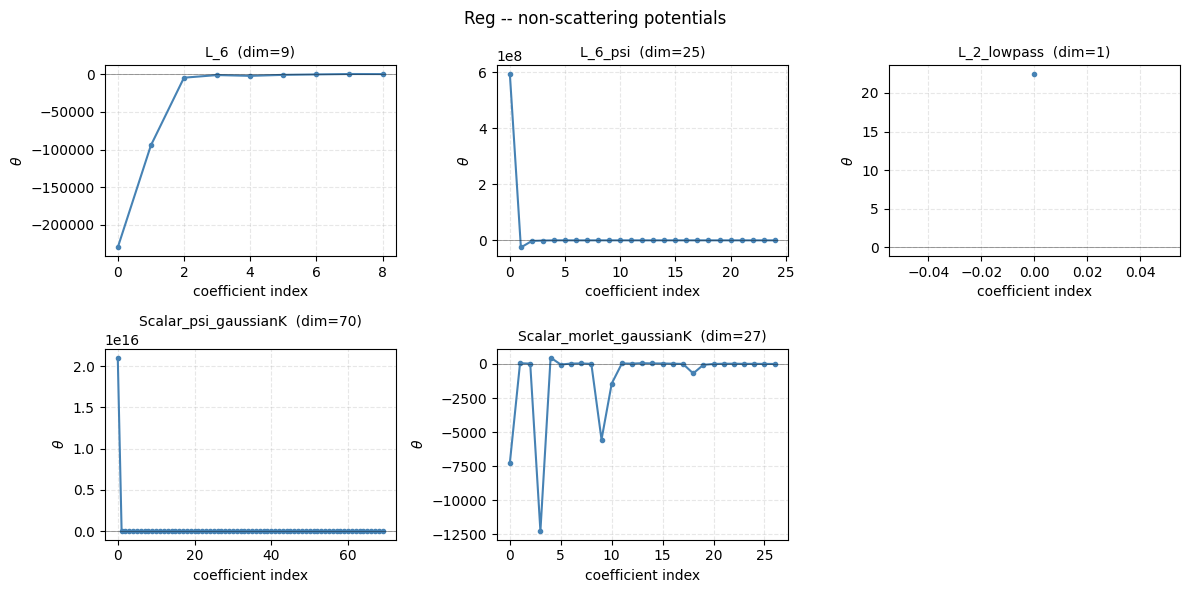

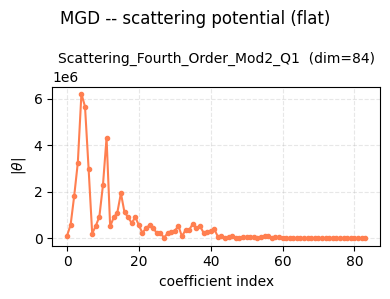

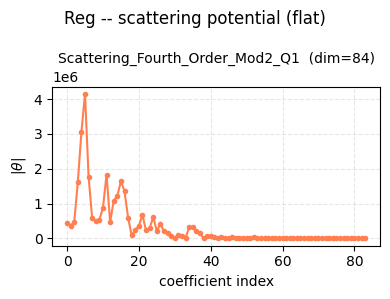

In [23]:
non_scattering_names = [k for k in mgd_vectors.keys() if k != COMPLEX_NAME]

plot_theta_by_potential(mgd_vectors, potential_names=non_scattering_names,
                         title='MGD -- non-scattering potentials')
plot_theta_by_potential(reg_vectors, potential_names=non_scattering_names,
                         title='Reg -- non-scattering potentials')

plot_theta_by_potential(mgd_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='MGD -- scattering potential (flat)')
plot_theta_by_potential(reg_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='Reg -- scattering potential (flat)')

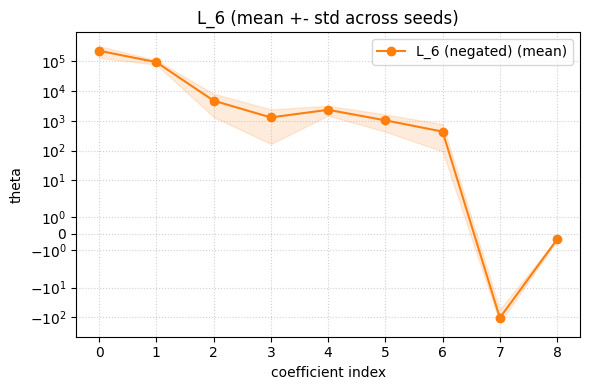

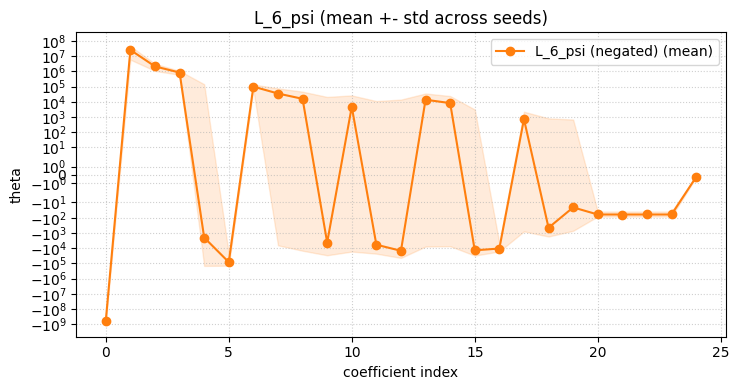

In [24]:
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
%matplotlib inline 
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6', terms, sign=-1)
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6_psi', terms, sign=-1)

## Sum of L6 psi and L6 terms 

[[ True False False  True False  True False  True  True]
 [ True False False False  True  True False  True  True]
 [ True False False  True  True  True  True  True  True]
 [ True False False  True  True  True False  True  True]
 [ True False False  True  True  True  True  True  True]
 [ True False False False False  True False  True  True]
 [ True False False False False  True False  True  True]
 [ True False False False  True  True False  True  True]
 [ True False False  True False  True False  True  True]
 [ True False False False False False  True  True  True]
 [ True False False  True False  True  True  True  True]
 [ True False  True  True  True  True  True  True  True]
 [ True False False  True  True  True False  True  True]
 [ True False False False  True False  True  True  True]
 [ True False False  True False  True False  True  True]
 [ True False False  True  True False  True  True  True]
 [ True False False False False  True  True  True  True]
 [ True False False False False

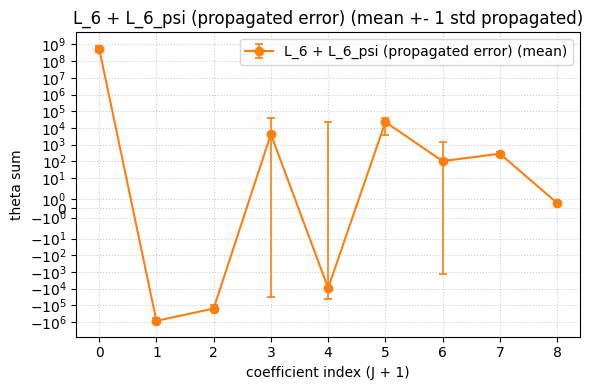

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_linear_potential_SUM_mean_std(theta_all, potentials,
                                       target_keys=('L_6', 'L_6_psi'),
                                       label=None, sign=1, known_dims=None,
                                       color='tab:orange', yscale='symlog',
                                       capsize=3):
    """
    Mean and propagated 1 std error bars for the SUM of two potentials.
    
    Explicitly uses error propagation (quadrature sum):
    1. Computes mean & std across seeds independently for both potentials.
    2. Groups 3 consecutive terms in key2 (3*J) via quadrature sum for stds:
       std_grouped = sqrt(std_a^2 + std_b^2 + std_c^2).
    3. Combines key1 and grouped key2 via quadrature sum:
       std_total = sqrt(std_key1^2 + std_grouped^2).
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]
    
    col_map = theta_column_map(potentials, n_features, known_dims=known_dims, verbose=False)
    
    for key in target_keys:
        if key not in col_map:
            raise KeyError(f"'{key}' not found in potentials: {list(potentials.keys())}")
            
    key1, key2 = target_keys
    start1, dim1 = col_map[key1]
    start2, dim2 = col_map[key2]
    
    slice1 = theta_np[:, start1:start1+dim1]      # (nseed, J+1)
    slice2 = theta_np[:, start2:start2+dim2]      # (nseed, 3J+1)
    
    J = dim1 - 1
    
    # aggregate psi within each seed
    psi = slice2[:, :3*J].reshape(-1, J, 3).sum(axis=-1)
    
    # append the constant
    psi = np.concatenate(
        [psi, slice2[:, -1][:, None]],
        axis=1
    )
    
    # total theta for each seed
    theta_total = sign * (slice1 + psi)
    print(theta_total > 0 ) 
    
    # now statistics
    final_mean = theta_total.mean(axis=0)
    final_std = theta_total.std(axis=0)
    
    for i, (m, s) in enumerate(zip(final_mean, final_std)):
        if m > 0:
            z = m / s if s > 0 else np.inf
            print(f"{i:2d}: mean={m:.4g}, std={s:.4g}, z={z:.2f}")
    
    # Plotting
    x = np.arange(dim1)
    default_name = f"{key1} + {key2} (propagated error)"
    label = label or f"{default_name}{' (negated)' if sign == -1 else ''} (mean)"
    
    plt.figure(figsize=(max(6, dim1 * 0.3), 4))
    plt.errorbar(
        x, final_mean, yerr=final_std, fmt='-o', color=color, label=label,
        capsize=capsize, elinewidth=1.2, capthick=1.2
    )
    
    if yscale != 'linear':
        plt.yscale(yscale)
        
    plt.title(f'{default_name} (mean +- 1 std propagated)')
    plt.xlabel('coefficient index (J + 1)')
    plt.ylabel('theta sum')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close('all') 

    if (final_mean < 0).any() and yscale == 'log':
        print(f"WARNING: {default_name} has negative values but yscale='log' -- "
              f"those points are invisible on the plot above. Use 'symlog' or 'linear'.")
        
plot_linear_potential_SUM_mean_std(reg_all, ref_potentials_reg) 

Theta_reg shape : (50, 272)
Theta_MGD shape : (50, 272)


,Theta_reg mean variance,Theta_MGD mean variance,Theta_reg median variance,Theta_MGD median variance,Theta_reg mean CV,Theta_MGD mean CV,Theta_reg mean SNR,Theta_MGD mean SNR
0,4.455270e+24,1.780510e+26,35366816.0,1.463698e+10,5.504886,34.499317,51.000996,6.858085


Mean correlation : 0.09240991916386719
Median correlation : 0.0757172126264172
{'L_6': (0, 9), 'L_6_psi': (9, 34), 'L_2_lowpass': (34, 35), 'Scattering_Fourth_Order_Mod2_Real_Q1': (132, 216), 'Scattering_Fourth_Order_Mod2_Imag_Q1': (216, 272), 'Scalar_psi_gaussianK': (35, 105), 'Scalar_morlet_gaussianK': (105, 132)}


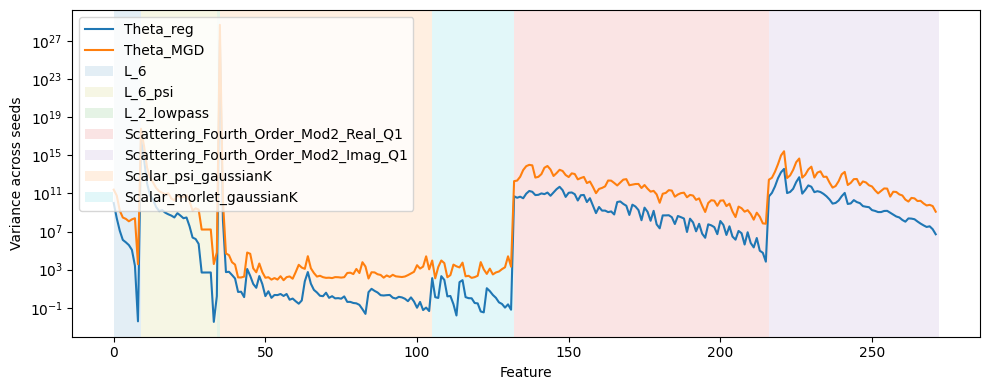

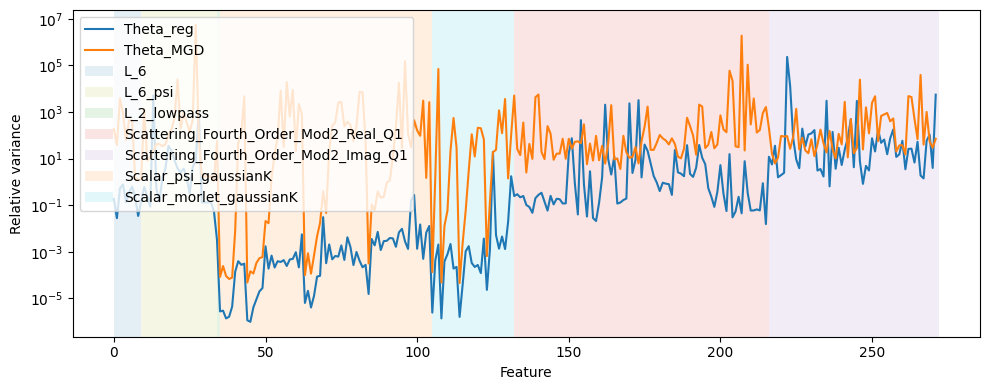

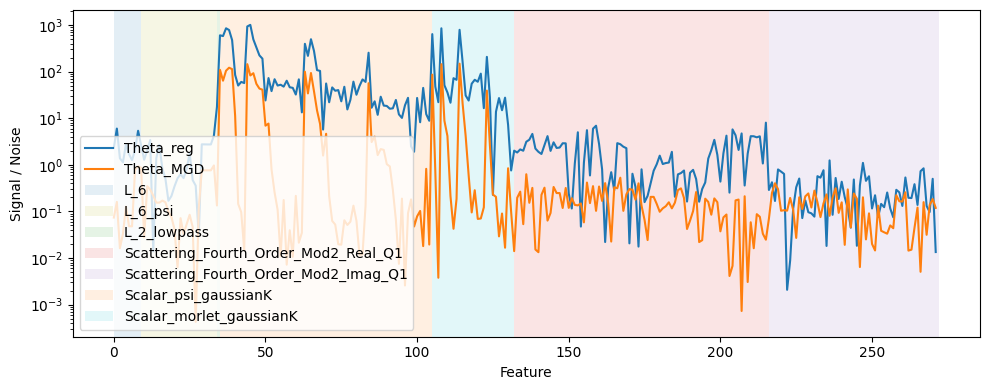

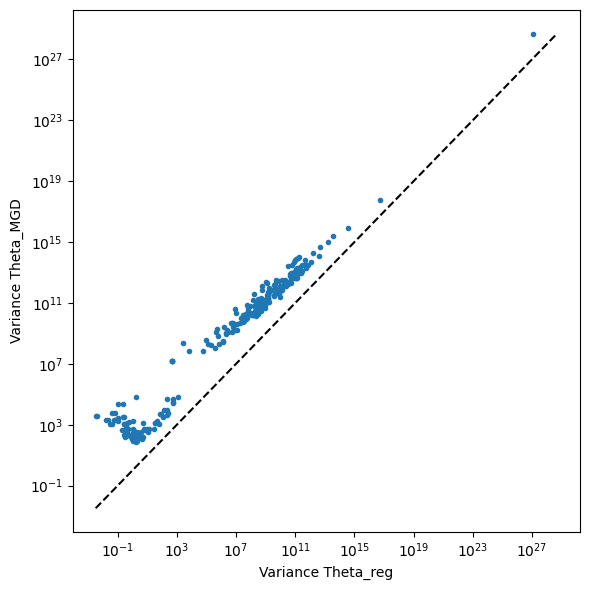

Largest Theta_reg variances
35 1.21183354e+27
9 5.0386143e+16
10 391654070000000.0
221 37034048000000.0
220 16397191000000.0
226 4963517300000.0
219 3912058800000.0
225 1534956300000.0
11 1083953900000.0
229 687397900000.0

Largest Theta_MGD variances
35 4.8429866e+28
9 6.011462e+17
10 8755951000000000.0
221 2636291500000000.0
220 957011300000000.0
226 455778170000000.0
225 186865790000000.0
219 115885740000000.0
137 98873770000000.0
138 87503020000000.0


In [ ]:
import pandas as pd

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive", 
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan", 
}

# ------------------------------------------------------------
# Use the currently loaded runs directly — no file load.
# reg_all / mgd_all were built earlier from `results` via
# torch.stack([final_theta_reg[s] for s in seeds_sorted]) etc.
# ------------------------------------------------------------
seeds = seeds_sorted

theta_reg = reg_all.detach().cpu().numpy()
theta_mgd = mgd_all.detach().cpu().numpy()

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape
assert n_features == n_features_reg == n_features_mgd, (
    "reg_all/mgd_all feature dim doesn't match n_features_reg/n_features_mgd "
    "computed earlier — check seeds_sorted and results are in sync."
)

%matplotlib inline
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr)

summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],
    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],
    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],
    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})
display(summary)

corrs = np.array([
    np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0, 1]
    for j in range(n_features)
])
print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

# ------------------------------------------------------------
# potential_ranges from the live reference potentials, via theta_column_map()
# (codes/check_potentials.py) -- single source of truth, same helper used for
# cell 18's family_ranges, instead of two independently hand-rolled loops
# that could silently diverge. Iterated in potential_colors' order so legend
# order matches the color dict below.
# ------------------------------------------------------------
reference_seed_name, reference_potentials, _ = find_matching_reference_potentials(
    reg_all, potentials_by_seed
)

col_map = theta_column_map(reference_potentials, n_features_reg)

missing_colors = [name for name in col_map if name not in potential_colors]
if missing_colors:
    raise KeyError(
        f"No entry in potential_colors for: {missing_colors} — "
        f"add colors for these or they won't be shaded in the plots."
    )

potential_ranges = {
    name: (col_map[name][0], col_map[name][0] + col_map[name][1])
    for name in potential_colors.keys() if name in col_map
}

total_from_potentials = max(b for _, b in potential_ranges.values())
assert total_from_potentials == n_features_reg == n_features_mgd, (
    f"Potential-range total ({total_from_potentials}) doesn't match the actual "
    f"feature dimension from disk (theta_reg={n_features_reg}, theta_MGD={n_features_mgd}). "
    f"This means {reference_seed_name}'s pruning differs from the pooled theta arrays — "
    f"check that all seeds in `seeds_sorted` were fit with the same active regions."
)
print(potential_ranges)

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all') 

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all') 

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all') 

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()
plt.close('all') 

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])

# Scale-resolved decomposition of the 4th-order scattering energy (Reg only)

Everything below uses **`Theta_reg`** exclusively (the only trustable fit). Reuses `ref_seed_reg`/`ref_potentials_reg` (already computed above via `find_matching_reference_potentials(reg_all, potentials_by_seed)`) so the theta layout matches the potentials used to decode indices.

Convention (verified against the actual `forward()` broadcast shapes, not the misleading inline comments -- see chat): for `Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1`, `Q=1`, so the fine pair `s1,s2` and the coarse `j` sit on the *same* octave grid. Index `0` = smallest scale (finest/highest-frequency); the largest index = largest scale, with the last coarse slot being the low-pass.

**Construction check (done below, not assumed):** both branches are built with `offset=1` (`include_diag=False`), so the exact diagonal `s1==s2` is structurally ABSENT from both -- the smallest available scale-lag is `|s1-s2|=1`. The Real branch additionally includes the coarse low-pass (`j` up to `J`), the Imag branch does not (`j` up to `J-1`). This is confirmed programmatically in the setup cell, not assumed from memory.

In [ ]:
# --- Item 0: Reg-only scale-resolved setup ---

theta_reg_energy = results[ref_seed_reg]['Theta_reg'][-1].detach().cpu()
phi_X_reg = compute_phi_X(ref_potentials_reg, x1).detach().cpu()

assert phi_X_reg.shape[-1] == theta_reg_energy.shape[-1], (
    f"phi_X_reg ({phi_X_reg.shape[-1]}) vs theta_reg_energy ({theta_reg_energy.shape[-1]}) mismatch -- "
    f"ref_potentials_reg's layout doesn't match Theta_reg for {ref_seed_reg}."
)

col_map_reg = theta_column_map(ref_potentials_reg, theta_reg_energy.shape[-1])
# theta_column_map returns {key: (start, dim)} -- NOT (start, end) -- convert explicitly,
# same convention as the notebook's earlier family_ranges/potential_ranges cells.
a_re, dim_re = col_map_reg[REAL_KEY]
b_re = a_re + dim_re
a_im, dim_im = col_map_reg[IMAG_KEY]
b_im = a_im + dim_im

pot_re_reg = ref_potentials_reg[REAL_KEY]
pot_im_reg = ref_potentials_reg[IMAG_KEY]

j_arr, s1_arr, s2_arr = decode_mod2_stq(pot_re_reg, verbose=True)
J_scatter = pot_re_reg.J
Q_scatter_reg = pot_re_reg.Q
print(f"Scattering potential J={J_scatter}, Q={Q_scatter_reg} (expect Q=1)")

# Construction check: is the exact diagonal present? What's the minimal lag?
has_diag = bool((s1_arr == s2_arr).any())
min_lag = int(np.abs(s1_arr - s2_arr).min())
print(f"Real branch: exact diagonal present = {has_diag}, minimal |s1-s2| = {min_lag}, "
      f"j range = [{j_arr.min()}, {j_arr.max()}] (J={J_scatter})")

energy_reg_percoef = (theta_reg_energy[None, :] * phi_X_reg).numpy()  # (n1, n_features)

energy_reg_real = energy_reg_percoef[:, a_re:b_re]                    # (n1, dim_re), real branch's own layout
energy_reg_imag_own = energy_reg_percoef[:, a_im:b_im]                # (n1, dim_im), imag branch's own layout
energy_reg_imag_remapped = expand_imag_to_real_indices(
    pot_im_reg, pot_re_reg, energy_reg_imag_own, index_convention='mod2',
)  # (n1, dim_re), zero-padded onto real's layout

mean_energy_real = energy_reg_real.mean(axis=0)              # (dim_re,)
mean_energy_imag_remapped = energy_reg_imag_remapped.mean(axis=0)

print(f"Real branch: {energy_reg_real.shape}, Imag remapped onto real layout: {energy_reg_imag_remapped.shape}")


In [29]:
p_im = ref_potentials_reg[IMAG_KEY]
print(type(p_im))
print('num_coefficients:', getattr(p_im, 'num_coefficients', 'MISSING'))
print('indices.shape:', tuple(p_im.indices.shape) if hasattr(p_im, 'indices') else 'MISSING')
print('has n_theta/num_theta/theta_dim:',
      {a: hasattr(p_im, a) for a in ('n_theta', 'num_theta', 'theta_dim')})

# full column map with the source of each width, printed
_ = theta_column_map(ref_potentials_reg, theta_reg_energy.shape[-1], verbose=True)

<class 'potentials.potentials_1d.Scattering_Fourth_Order_Mod2_Imag_1d'>
num_coefficients: 56
indices.shape: (3, 56)
has n_theta/num_theta/theta_dim: {'n_theta': False, 'num_theta': False, 'theta_dim': False}
L_6                                     9  [   0:9   ]  'num_coefficients'
L_6_psi                                25  [   9:34  ]  'num_coefficients'
L_2_lowpass                             1  [  34:35  ]  'num_coefficients'
Scalar_psi_gaussianK                   70  [  35:105 ]  'num_coefficients'
Scalar_morlet_gaussianK                27  [ 105:132 ]  'num_coefficients'
Scattering_Fourth_Order_Mod2_Real_Q1    84  [ 132:216 ]  'num_coefficients'
Scattering_Fourth_Order_Mod2_Imag_Q1    56  [ 216:272 ]  'num_coefficients'


## 1. Scale-pair heatmap per coarse resolution `j`

For each `j`, scatter of mean Reg energy `\theta_{reg} \cdot \phi(x)` over the `(s1,s2)` grid (symmetrized: both `(s1,s2)` and `(s2,s1)` plotted). Checks whether energy concentrates near the diagonal (adjacent, local scale-pairs) or spreads to distant `(s1,s2)` pairs (genuine long-range cross-scale coupling), and how that pattern changes as the averaging scale `j` coarsens.

In [ ]:
%matplotlib inline

j_values = sorted(set(j_arr.tolist()))
n_cols = 3
n_rows = math.ceil(len(j_values) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), squeeze=False)

vmax = np.abs(mean_energy_real).max()
for i, jv in enumerate(j_values):
    ax = axes[i // n_cols][i % n_cols]
    mask = (j_arr == jv)
    sc = ax.scatter(s1_arr[mask], s2_arr[mask], c=mean_energy_real[mask],
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=70, edgecolors='k', linewidths=0.3)
    ax.scatter(s2_arr[mask], s1_arr[mask], c=mean_energy_real[mask],
               cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=70, edgecolors='k', linewidths=0.3)  # symmetrized
    ax.plot([0, J_scatter], [0, J_scatter], color='black', lw=0.5, alpha=0.4)
    ax.set_title(f'j = {jv}  (n={mask.sum()})')
    ax.set_xlabel('s1')
    ax.set_ylabel('s2')
    ax.set_xlim(-0.5, J_scatter - 0.5)
    ax.set_ylim(-0.5, J_scatter - 0.5)
    fig.colorbar(sc, ax=ax, fraction=0.046)

for k in range(len(j_values), n_rows * n_cols):
    axes[k // n_cols][k % n_cols].axis('off')

fig.suptitle(f'Reg scattering energy (real branch), mean over samples, per coarse scale j  ({ref_seed_reg})')
fig.tight_layout()
plt.show()
plt.close('all') 


## 2. Fixed-partner-scale slices: energy vs `s1` at fixed `s2 = k'`

One panel per representative reference scale `s2`, one curve per coarse resolution `j`. This is the scale-decay profile: how correlation with a fixed scale falls off as the partner scale `s1` moves away, and whether finer `j` sharpens that decay relative to coarser `j`.

In [ ]:
%matplotlib inline

s2_reference_values = sorted(set(s2_arr.tolist()))
picks = sorted(set([s2_reference_values[0],
                     s2_reference_values[len(s2_reference_values) // 2],
                     s2_reference_values[-1]]))

fig, axes = plt.subplots(1, len(picks), figsize=(5 * len(picks), 4), squeeze=False)
axes = axes[0]

cmap_j = plt.get_cmap('viridis', max(j_values) + 1)
for ax, s2_ref in zip(axes, picks):
    for jv in j_values:
        mask = (j_arr == jv) & (s2_arr == s2_ref)
        if mask.sum() == 0:
            continue
        order = np.argsort(s1_arr[mask])
        ax.plot(s1_arr[mask][order], mean_energy_real[mask][order],
                marker='o', color=cmap_j(jv), label=f'j={jv}')
    ax.axhline(0, color='black', lw=0.5, alpha=0.5)
    ax.axvline(s2_ref, color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f"s2 (k') = {s2_ref}")
    ax.set_xlabel('s1 (k)')
    ax.set_ylabel(r'$\theta_{reg} \cdot \phi(x)$')

axes[-1].legend(fontsize=7, ncol=2, title='j')
fig.suptitle(f'Reg scattering energy vs s1, fixed s2, per j  ({ref_seed_reg})')
fig.tight_layout()
plt.show()
plt.close('all') 


## 3. Scale-lag collapse: energy vs `|s1 - s2|`, per `j`

All `(s1,s2)` pairs pooled by scale-lag, one decay curve per `j` (note: minimal lag is 1, not 0 -- the exact diagonal is structurally absent, see item 0). A log-normal cascade predicts roughly log-linear decay in lag; deviations (plateaus, heavy tails) are an intermittency signature comparable against the MRW/fBm intermittency parameter this experiment fits against.

In [ ]:
%matplotlib inline

lag = np.abs(s1_arr - s2_arr)

fig, ax = plt.subplots(figsize=(7, 4.5))
for jv in j_values:
    mask = (j_arr == jv)
    if mask.sum() == 0:
        continue
    lag_j = lag[mask]
    val_j = np.abs(mean_energy_real[mask])
    lag_unique, inv = np.unique(lag_j, return_inverse=True)
    val_avg = np.array([val_j[inv == i].mean() for i in range(len(lag_unique))])
    ax.plot(lag_unique, val_avg, marker='o', color=cmap_j(jv), label=f'j={jv}')

ax.set_yscale('log')
ax.set_xlabel('scale lag |s1 - s2|  (minimum is 1, not 0 -- see item 0)')
ax.set_ylabel(r'$|\theta_{reg} \cdot \phi(x)|$ (averaged over pairs at that lag)')
ax.legend(fontsize=7, ncol=2, title='j')
ax.set_title(f'Reg scattering energy vs scale-lag, per j  ({ref_seed_reg})')
fig.tight_layout()
plt.show()
plt.close('all') 


## 4. Marginal energy vs coarse resolution `j`

Sum of Reg energy over all `(s1,s2)` pairs at fixed `j`. Complements `build_octave_energy_comparison`'s existing `interacting` per-octave total by making this breakdown self-contained here (computed straight from the same `(j,s1,s2)`-indexed energy array as items 1-3), and cross-checked against it below if that variable is already in scope.

In [ ]:
%matplotlib inline

marginal_per_j = np.array([mean_energy_real[j_arr == jv].sum() for jv in j_values])
marginal_abs_per_j = np.array([np.abs(mean_energy_real[j_arr == jv]).sum() for jv in j_values])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(j_values, marginal_per_j, marker='o', label='signed sum')
ax.plot(j_values, marginal_abs_per_j, marker='s', label='sum of |.|')
ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coarse scale j')
ax.set_ylabel('total Reg energy at that j')
ax.set_title(f'Marginal Reg scattering energy vs coarse resolution j  ({ref_seed_reg})')
ax.legend()
fig.tight_layout()
plt.show()
plt.close('all') 

print("Per-j signed sum:", dict(zip(j_values, marginal_per_j)))
if 'energy_reg' in globals() and 'interacting' in energy_reg:
    print("\nCross-check -- build_octave_energy_comparison's 'interacting' totals (energy_reg), for comparison:")
    print(energy_reg['interacting'])
else:
    print("\n(energy_reg['interacting'] not in scope here -- run the octave-energy-comparison cell above first to cross-check.)")


## 5. Near-diagonal (local) vs long-range cross-scale coupling

The exact diagonal `s1==s2` is structurally absent (item 0: `offset=1`), so this splits on scale-lag instead: minimal-lag pairs (`|s1-s2|=1`, adjacent scales -- the closest thing to "local self-correlation" available here) vs all longer-lag pairs (genuine cross-octave coupling), tracked per `j`. A compact intermittency indicator, comparable across seeds or later across a Re-number sweep in `jets`.

In [ ]:
%matplotlib inline

near_diag_mask = (lag == lag.min())
print(f"Near-diagonal bucket uses lag == {lag.min()} ({near_diag_mask.sum()} of {len(lag)} coefficients).")

near_per_j = np.array([np.abs(mean_energy_real[(j_arr == jv) & near_diag_mask]).sum() for jv in j_values])
far_per_j = np.array([np.abs(mean_energy_real[(j_arr == jv) & ~near_diag_mask]).sum() for jv in j_values])

fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
xpos = np.arange(len(j_values))
ax.bar(xpos - width / 2, near_per_j, width, label=f'near-diagonal (|s1-s2|={lag.min()})')
ax.bar(xpos + width / 2, far_per_j, width, label='longer-range (|s1-s2|>{})'.format(lag.min()))
ax.set_xticks(xpos)
ax.set_xticklabels(j_values)
ax.set_xlabel('coarse scale j')
ax.set_ylabel('total |Reg energy|')
ax.set_title(f'Near-diagonal vs long-range Reg energy, per j  ({ref_seed_reg})')
ax.legend()
fig.tight_layout()
plt.show()
plt.close('all') 

ratio = np.divide(far_per_j, near_per_j, out=np.full_like(far_per_j, np.nan), where=near_per_j > 0)
print("long-range / near-diagonal ratio per j:", dict(zip(j_values, ratio)))


## 6. Real vs imaginary scale structure

Repeats item 1's heatmap separately for the Real and remapped-Imag branches (Reg energy). The Imag branch has no coarse low-pass slot (`j` only up to `J-1`, see item 0) while Real does (`j` up to `J`) -- panels for `j=J` will be empty for Imag by construction, not a bug. Checks whether the imaginary (phase-sensitive) part has a qualitatively different `(s1,s2)` structure from the real part, or just a smaller-magnitude version of the same one.

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(2, len(j_values), figsize=(3.6 * len(j_values), 7.5), squeeze=False)

vmax_re = np.abs(mean_energy_real).max()
vmax_im = np.abs(mean_energy_imag_remapped).max()

for col, jv in enumerate(j_values):
    mask = (j_arr == jv)

    ax_re = axes[0][col]
    sc_re = ax_re.scatter(s1_arr[mask], s2_arr[mask], c=mean_energy_real[mask],
                           cmap='RdBu_r', vmin=-vmax_re, vmax=vmax_re, s=60, edgecolors='k', linewidths=0.3)
    ax_re.scatter(s2_arr[mask], s1_arr[mask], c=mean_energy_real[mask],
                  cmap='RdBu_r', vmin=-vmax_re, vmax=vmax_re, s=60, edgecolors='k', linewidths=0.3)
    ax_re.set_title(f'Real, j={jv}')
    ax_re.set_xlabel('s1'); ax_re.set_ylabel('s2')

    ax_im = axes[1][col]
    sc_im = ax_im.scatter(s1_arr[mask], s2_arr[mask], c=mean_energy_imag_remapped[mask],
                           cmap='RdBu_r', vmin=-vmax_im, vmax=vmax_im, s=60, edgecolors='k', linewidths=0.3)
    ax_im.scatter(s2_arr[mask], s1_arr[mask], c=mean_energy_imag_remapped[mask],
                  cmap='RdBu_r', vmin=-vmax_im, vmax=vmax_im, s=60, edgecolors='k', linewidths=0.3)
    ax_im.set_title(f'Imag (remapped), j={jv}')
    ax_im.set_xlabel('s1'); ax_im.set_ylabel('s2')

fig.colorbar(sc_re, ax=axes[0].tolist(), fraction=0.02, pad=0.01, label='Real energy')
fig.colorbar(sc_im, ax=axes[1].tolist(), fraction=0.02, pad=0.01, label='Imag energy')
fig.suptitle(f'Real vs remapped-Imag Reg scattering energy, per j  ({ref_seed_reg})')
plt.show()
plt.close('all') 


## 7. Typical vs rare events, scale-resolved

Reuses `samples`/`selected_samples.pt` (`typical`/`rare` categories, loaded earlier in the notebook) but evaluated against `ref_potentials_reg` and `theta_reg_energy` (Reg only, unlike the existing flat per-coefficient Real/Imag plot above which uses MGD/`ENERGY_SEED`), then aggregated into the scale-lag view from item 3, split by category. Checks whether rare/intermittent events shift energy toward small-lag/fine-`j` (localized bursts) vs longer-range coupling in typical events.

Requires `samples` to already be loaded (the `selected_samples.pt` cell above) -- skips with a message if not.

In [ ]:
%matplotlib inline

if 'samples' not in globals():
    print("`samples` not loaded (selected_samples.pt cell above wasn't run) -- skipping item 7.")
else:
    sample_energy_reg = {}   # category -> (n_samples, n_features), Reg-sourced
    for category, tensors in samples.items():
        x_cat = torch.stack([t.to(device) for t in tensors], dim=0)
        if x_cat.ndim == 2:
            x_cat = x_cat.unsqueeze(1)
        phi_cat_reg = compute_phi_X(ref_potentials_reg, x_cat).detach().cpu()
        assert phi_cat_reg.shape[-1] == theta_reg_energy.shape[-1], (
            f"'{category}': phi_X has {phi_cat_reg.shape[-1]} features, theta_reg_energy has "
            f"{theta_reg_energy.shape[-1]} -- selected_samples.pt's preprocessing doesn't match "
            f"{ref_seed_reg}'s fitted potentials."
        )
        sample_energy_reg[category] = (theta_reg_energy[None, :] * phi_cat_reg).numpy()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    category_style = {
        "typical": dict(color="tab:blue", lw=1.5, marker='o'),
        "rare":    dict(color="tab:red",  lw=1.5, marker='s'),
    }
    for category, energy in sample_energy_reg.items():
        energy_real_cat = energy[:, a_re:b_re]                        # (n_cat, dim_re)
        val_cat = np.abs(energy_real_cat).mean(axis=0)                # mean |energy| over this category's samples
        lag_unique, inv = np.unique(lag, return_inverse=True)
        val_avg = np.array([val_cat[inv == i].mean() for i in range(len(lag_unique))])
        style = category_style.get(category, dict(lw=1.5, marker='.'))
        ax.plot(lag_unique, val_avg, label=category, **style)

    ax.set_yscale('log')
    ax.set_xlabel('scale lag |s1 - s2|  (minimum is 1, not 0)')
    ax.set_ylabel(r'mean $|\theta_{reg} \cdot \phi(x)|$ over category samples')
    ax.set_title(f'Reg scattering energy vs scale-lag, typical vs rare  ({ref_seed_reg})')
    ax.legend(title='event type')
    fig.tight_layout()
    plt.show()
    plt.close('all') 


## 8. Fisher vs Dirichlet normalisation of $\theta$ (t = 1, $\sigma$ = 3.5)

Two invariant norms on $\theta$ (both covariant under $\varphi\to A\varphi$, $\theta\to A^{-\top}\theta$): $\Sigma=\mathrm{Cov}_{p^*}(\varphi)$ (Fisher — statistical distinguishability) and $G=\mathbb{E}[\nabla_x\varphi\nabla_x\varphi^\top]$ (Dirichlet — force-field contribution). $\sigma=3.5$ is the only $\sigma$ on disk here, so it's trivially "the largest available". $\theta^*$ is `Theta_reg[-1]` for `ref_seed_reg` (`theta_reg_energy` / `ref_potentials_reg` / `phi_X_reg` / `col_map_reg`, all already built above); the ensemble standing in for $p^*$ at $t=1$ is `x1` itself — this notebook never loads generated SDE particle trajectories (`results` only keeps `theta_t`/`Theta_reg`/`t`), and x1 is exactly what the fit's moment-matching target already treats as the $p^*$ sample.

**Family caveat:** `terms` has no third-order scattering potential here — only `L_6`, `L_6_psi`, `L_2_lowpass`, `Scalar_psi_gaussianK`, `Scalar_morlet_gaussianK`, and the 4th-order Real/Imag_Q1 pair. $\varphi_3$ from the task spec doesn't exist in this fit and is skipped rather than guessed at; $\varphi_4$ = the Real+Imag scattering pair (`COMPLEX_NAME`).

In [ ]:
theta_star = theta_reg_energy                        # (n_features,), Theta_reg[-1] for ref_seed_reg == "theta1 ~ theta*"
phi_X_star = phi_X_reg                                # (n1, n_features), phi(x1) under the SAME fitted potentials
potentials_star = ref_potentials_reg

n_features = theta_star.shape[-1]
family_ranges_star = {name: (a, a + d) for name, (a, d) in col_map_reg.items()}

theta_np = theta_star.detach().cpu().numpy()

print(f"theta* from seed {ref_seed_reg}, {n_features} features, ensemble = x1 ({x1.shape[0]} samples)")
for name, (a, b) in family_ranges_star.items():
    print(f"  {name:45s} dim={b - a}")

**$\Sigma$ estimator:** raw sample covariance of $\varphi(x_1)$ over the n1 real-data samples (`np.cov(..., ddof=1)`), no shrinkage — the condition numbers below are the actual ill-conditioning of this ensemble, not something a regulariser is hiding.

**G estimator:** each potential class implements its own analytic `.grad(x)` (the exact object the SDE's drift assembly uses, e.g. `sde_routines.py`'s `grad_potential = torch.cat((grad_potential, potential.grad(x)), dim=1)`) — several potentials here (`Scalar_psi_gaussianK`/`Scalar_morlet_gaussianK`) wrap `forward()` in `torch.no_grad()`, so a generic autograd Jacobian wouldn't even work here. $G=\mathbb{E}[\nabla\varphi\nabla\varphi^\top]$ is built directly from `.grad(x)` on the SAME x1 ensemble as $\Sigma$.

In [ ]:
def sample_covariance(phi):
    phi_np = phi.detach().cpu().numpy() if torch.is_tensor(phi) else np.asarray(phi)
    return np.cov(phi_np, rowvar=False, ddof=1)

def compute_phi_grad_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    """Concatenate each potential's own analytic grad(x) along the coefficient
    axis -> (n, d, T): the exact object the MGD force field is built from
    (compare sde_routines.py's grad_potential = torch.cat((grad_potential,
    potential.grad(x)), dim=1)), NOT a generic autograd Jacobian.
    chunk_size batches the sample dim for the SAME reason compute_phi_X does --
    measured directly: .grad() on Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1
    hits the identical ~5.9GB single-allocation wall as forward() does."""
    def _grad_one_chunk(x_chunk):
        grad_potential = None
        for p in potentials.values():
            g = p.grad(x_chunk)
            grad_potential = g if grad_potential is None else torch.cat((grad_potential, g), dim=1)
        return grad_potential.detach()

    if chunk_size is None or x.shape[0] <= chunk_size:
        return _grad_one_chunk(x)
    return torch.cat([_grad_one_chunk(x[i:i + chunk_size]) for i in range(0, x.shape[0], chunk_size)], dim=0)

Sigma_full = sample_covariance(phi_X_star)

# (n1, n_features, T) -- roughly n1*n_features*T*4 bytes; subsample x1 below if this OOMs
J_star = compute_phi_grad_X(potentials_star, x1)
G_full = (torch.einsum('ndt,net->de', J_star, J_star) / J_star.shape[0]).cpu().numpy()

Sigma_by_family = {name: Sigma_full[a:b, a:b] for name, (a, b) in family_ranges_star.items()}
G_by_family = {name: G_full[a:b, a:b] for name, (a, b) in family_ranges_star.items()}

print(f"{'family':45s} {'dim':>5s} {'cond(Sigma)':>14s} {'cond(G)':>14s}")
for name, (a, b) in family_ranges_star.items():
    print(f"{name:45s} {b - a:5d} {np.linalg.cond(Sigma_by_family[name]):14.3g} {np.linalg.cond(G_by_family[name]):14.3g}")
print(f"{'[full stacked phi]':45s} {n_features:5d} {np.linalg.cond(Sigma_full):14.3g} {np.linalg.cond(G_full):14.3g}")

Eigenvalue spectra per family, not just cond(): a large cond($\Sigma$) or cond(G) means several scattering moments are (near-)redundant under this ensemble/coordinates, so the raw-$\theta$ spread there is partly that degeneracy, not physics. Whitening below does NOT fix this — it just makes it explicit via the spectrum.

In [ ]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in family_ranges_star:
    color = potential_colors.get(name)
    axes[0].plot(np.sort(np.linalg.eigvalsh(Sigma_by_family[name]))[::-1], marker='o', ms=3, label=name, color=color)
    axes[1].plot(np.sort(np.linalg.eigvalsh(G_by_family[name]))[::-1], marker='o', ms=3, label=name, color=color)
for ax, title in zip(axes, [r'eig($\Sigma$)', 'eig(G)']):
    ax.set_yscale('log'); ax.set_xlabel('rank'); ax.set_title(f'{title}, per family')
axes[0].legend(fontsize=7)
fig.tight_layout()
plt.show()
plt.close('all') 

Raw $|\theta|$ and three normalisations, diagonal first (dimensionally safe): $\Sigma_{ii}^{1/2}\theta_i$, $G_{ii}^{1/2}\theta_i$. The full-matrix $\Sigma^{1/2}\theta$ / $G^{1/2}\theta$ mix units across $\varphi$ components, so they're computed only AFTER rescaling every $\varphi_i$ to unit sample sd (dividing by $\sqrt{\Sigma_{ii}}$, the SAME rescaling applied to both matrices) — flagged inline below rather than silently applied.

In [ ]:
def sym_sqrt(M):
    w, V = np.linalg.eigh((M + M.T) / 2)
    w = np.clip(w, 0, None)
    return V @ np.diag(np.sqrt(w)) @ V.T

diag_sigma = np.diag(Sigma_full)
diag_G = np.diag(G_full)

theta_hat_sigma_diag = np.sqrt(diag_sigma) * theta_np
theta_hat_G_diag = np.sqrt(diag_G) * theta_np

# Full-matrix sqrt only after rescaling phi_i -> phi_i / sd(phi_i) (unit sd under p*),
# theta_i -> theta_i * sd(phi_i) covariantly -- using Sigma's own diagonal for BOTH
# matrices so Sigma_tilde/G_tilde are on the same footing (see markdown above).
sd_phi = np.sqrt(diag_sigma)
inv_sd_phi = np.divide(1.0, sd_phi, out=np.zeros_like(sd_phi), where=sd_phi > 0)
Sigma_tilde = (inv_sd_phi[:, None] * Sigma_full) * inv_sd_phi[None, :]
G_tilde = (inv_sd_phi[:, None] * G_full) * inv_sd_phi[None, :]
theta_tilde = sd_phi * theta_np

theta_hat_sigma_full = sym_sqrt(Sigma_tilde) @ theta_tilde
theta_hat_G_full = sym_sqrt(G_tilde) @ theta_tilde

norm_summary = pd.DataFrame([
    {
        'family': name, 'dim': b - a,
        'median|theta|': np.median(np.abs(theta_np[a:b])),
        'median|theta_hat_Sigma_diag|': np.median(np.abs(theta_hat_sigma_diag[a:b])),
        'median|theta_hat_G_diag|': np.median(np.abs(theta_hat_G_diag[a:b])),
        'median|theta_hat_Sigma_full|': np.median(np.abs(theta_hat_sigma_full[a:b])),
        'median|theta_hat_G_full|': np.median(np.abs(theta_hat_G_full[a:b])),
    }
    for name, (a, b) in family_ranges_star.items()
])
display(norm_summary)

$\theta^\top\Sigma\theta / \theta^\top G\theta$ is a squared length scale (G carries $\nabla_x$); componentwise $(\Sigma_{ii}/G_{ii})^{1/2}$ is the same thing per coefficient. For wavelet-indexed $\varphi$ at octave j this should track $2^{2j}$ if the observable is scale-local — a cheap consistency check on both estimators, checked here on $\varphi_4$'s real branch (`j_arr` from `decode_mod2_stq(pot_re_reg)`, already decoded above).

In [ ]:
ratio_global = {}
for name, (a, b) in family_ranges_star.items():
    th = theta_np[a:b]
    num, den = th @ Sigma_by_family[name] @ th, th @ G_by_family[name] @ th
    ratio_global[name] = num / den if den != 0 else np.nan
ratio_global['[full]'] = (theta_np @ Sigma_full @ theta_np) / (theta_np @ G_full @ theta_np)

print(f"{'family':45s} {'theta^T Sigma theta / theta^T G theta':>38s}")
for name, r in ratio_global.items():
    print(f"{name:45s} {r:38.4g}")

a_re4, b_re4 = family_ranges_star[REAL_KEY]
len2_per_k = diag_sigma[a_re4:b_re4] / diag_G[a_re4:b_re4]     # squared length scale, per phi4 (real) coefficient

j_vals_arr = np.array(sorted(set(j_arr.tolist())))
med_len2 = np.array([np.median(len2_per_k[j_arr == jv]) for jv in j_vals_arr])

%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 4.5))
for jv in j_vals_arr:
    mask = j_arr == jv
    ax.scatter(np.full(mask.sum(), jv), len2_per_k[mask], color=cmap_j(jv), alpha=0.5, s=18)
ax.plot(j_vals_arr, med_len2, color='black', marker='o', label='median per j')
ax.plot(j_vals_arr, med_len2[0] * 4.0 ** (j_vals_arr - j_vals_arr[0]), 'k--', lw=1, label=r'$2^{2j}$ reference')
ax.set_yscale('log')
ax.set_xlabel('coarse scale j'); ax.set_ylabel(r'$\Sigma_{kk}/G_{kk}$')
ax.set_title(r'$\phi_4$ (real branch): length-scale$^2$ vs $j$')
ax.legend()
fig.tight_layout()
plt.show()
plt.close('all') 

**Main target:** $\varphi_4$'s normalised couplings vs scale j (real-branch layout; diagonal $\Sigma$/G only — the full-matrix version mixes $\varphi_4$ with every other family's units). Log-log, with the consecutive-j local power-law slope. Question: does the orders-of-magnitude spread in raw $\theta$ survive under BOTH metrics, or collapse under one — i.e. was the spread physics or parametrisation?

In [ ]:
theta_re4 = theta_np[a_re4:b_re4]
theta_hat_S4 = np.sqrt(diag_sigma[a_re4:b_re4]) * theta_re4
theta_hat_G4 = np.sqrt(diag_G[a_re4:b_re4]) * theta_re4

def median_abs_by(index_arr, vals, bins):
    return np.array([np.median(np.abs(vals[index_arr == b])) for b in bins])

series4 = {
    'raw |theta|': median_abs_by(j_arr, theta_re4, j_vals_arr),
    r'$\hat\theta$ (Sigma diag)': median_abs_by(j_arr, theta_hat_S4, j_vals_arr),
    r'$\hat\theta$ (G diag)': median_abs_by(j_arr, theta_hat_G4, j_vals_arr),
}

j_pos = j_vals_arr > 0   # j=0 (lowpass) has no log-log slope
%matplotlib inline
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, vals in series4.items():
    ax.loglog(j_vals_arr[j_pos], vals[j_pos], marker='o', label=label)
ax.set_xlabel('scale j'); ax.set_ylabel(r"median $|\cdot|$ over $(k,k')$ at that $j$")
ax.set_title(r'$\phi_4$: raw vs normalised couplings vs $j$')
ax.legend()
fig.tight_layout()
plt.show()
plt.close('all') 

print(f"{'series':30s} {'mean local log-log slope':>28s}")
for label, vals in series4.items():
    log_j, log_v = np.log(j_vals_arr[j_pos]), np.log(np.clip(vals[j_pos], 1e-300, None))
    slopes = np.diff(log_v) / np.diff(log_j)
    print(f"{label:30s} {np.nanmean(slopes):28.3f}")

Same question against the scale lag $|k-k'|$ (reusing `lag` from the earlier scattering-energy section, item 0) rather than j — $\varphi_4$ couples PAIRS of scales, so the lag axis is the natural (k,k') summary.

In [ ]:
raw_by_var = {
    'raw |theta|': theta_re4,
    r'$\hat\theta$ (Sigma diag)': theta_hat_S4,
    r'$\hat\theta$ (G diag)': theta_hat_G4,
}
lag_vals = np.array(sorted(set(lag.tolist())))

%matplotlib inline
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, vals in raw_by_var.items():
    med_by_lag = np.array([np.median(np.abs(vals[lag == lv])) for lv in lag_vals])
    ax.loglog(lag_vals[lag_vals > 0], med_by_lag[lag_vals > 0], marker='o', label=label)
ax.set_xlabel("scale lag |s1 - s2|  (k, k')")
ax.set_ylabel("median |.| at that lag")
ax.set_title(r"$\phi_4$: raw vs normalised couplings vs $(k,k')$ lag")
ax.legend()
fig.tight_layout()
plt.show()
plt.close('all') 

**Estimation caveat, checked not assumed:** $\Sigma$ needs $\sim$8th-order moments of the field ($\varphi_4$ is quartic in x, $\Sigma=\mathrm{Cov}(\varphi_4)$); G needs only $\sim$6th ($\nabla\varphi_4$ is cubic). With Lagrangian-turbulence tails, $\Sigma$ may be poorly converged where G is fine. Checked below by re-estimating both from growing subsamples of the SAME x1 ensemble (log-x axis), tracking $\varphi_4$'s smallest/median/largest-j diagonal entries — this determines which normalisation is actually reportable.

In [ ]:
track_idx = {
    f'j={j_vals_arr.min()}': int(np.where(j_arr == j_vals_arr.min())[0][0]),
    f'j={j_vals_arr[len(j_vals_arr)//2]}': int(np.where(j_arr == j_vals_arr[len(j_vals_arr)//2])[0][0]),
    f'j={j_vals_arr.max()}': int(np.where(j_arr == j_vals_arr.max())[0][0]),
}

phi4_re_np = phi_X_star[:, a_re4:b_re4].detach().cpu().numpy()
J4 = J_star[:, a_re4:b_re4, :]                        # (n1, dim_re, T), phi4 rows of the full Jacobian

n_grid = np.unique(np.round(np.geomspace(50, x1.shape[0], 14)).astype(int))
Sigma_conv = {name: [] for name in track_idx}
G_conv = {name: [] for name in track_idx}
for n in n_grid:
    cov_n = np.cov(phi4_re_np[:n], rowvar=False, ddof=1)
    G_n = (torch.einsum('ndt,net->de', J4[:n], J4[:n]) / n).cpu().numpy()
    for name, idx in track_idx.items():
        Sigma_conv[name].append(cov_n[idx, idx])
        G_conv[name].append(G_n[idx, idx])

%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name in track_idx:
    axes[0].plot(n_grid, Sigma_conv[name], marker='o', label=name)
    axes[1].plot(n_grid, G_conv[name], marker='o', label=name)
for ax, title in zip(axes, [r'$\Sigma_{kk}$ vs subsample $n$', r'$G_{kk}$ vs subsample $n$']):
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('n'); ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle(r'$\phi_4$ convergence, same x1 subsamples for both estimators')
fig.tight_layout()
plt.show()
plt.close('all') 

print("If Sigma_kk is still drifting at n=n1 while G_kk has flattened out, "
      "Sigma is the one to distrust for reporting -- use G-based normalisation instead.")